# Vulcan Training 2.5 — ROI-seeded Nuclear Scaling U-Net

**2.5 is the ROI-seeded sibling of 2.0.** Same class heads, model, loss, metrics, inference and Section 18 gates; the classical patch generator and the review suite are replaced by the Section 9.8 Fiji-ROI importer as the patch source. `label_source="roi"` trains on the four hand-drawn ROI sets only; `"roi+classical"` adds classical filler (weighted below ROI) to test faithfulness on new data without hand-segmenting it. Run both against the same held-out gold set and compare Section 18 gates.

Built from `Vulcan_1_2_training_plan.md` (the canonical spec; the model is
named **Vulcan_2.0**) on top of `vulcan_training_1_1.ipynb`. The geometry
core, acquisition metadata, and histogram-safe IO are carried over verbatim.
Everything the plan adds is behind a **config flag** so that each phase is a
config diff and a run ID, not a code fork — that is the only way Section 11's
attribution warning survives maximal scope.

## Phase 0 finding (from the 1.1 source, before any data was pulled)

The plan's primary hypothesis was that `circularity >= 0.4` kept elongated
early nuclei *out* of the label set. The 1.1 code is worse than that: three
independent mechanisms turned them into **negative** examples.

1. `detect_nucleus_adaptive._clean_and_gate` returned `None` below
   `nucleus_min_circ = 0.40`; the best-z scan then reported no nucleus and
   `process_timepoint` emitted the droplet as a `no_nucleus` **hard negative**
   (`droplet=1, nucleus=0`). An elongated nucleus was labeled "empty droplet".
2. The Stage-2 gate is a RANSAC **circle** fit on NPC puncta. Elongated
   envelopes and partial early rings fail it -> `gate_fail`, same label.
3. `generation_min_timepoint = 2` dropped t=0-1 entirely and
   `timepoint_patch_weights = (0.25, 0.25, 0.5, 0.5, 1, 2, 3, 4, 4, 5)`
   *down*-weighted t=2-3 by 2-4x — the opposite of plan Section 5.3.

So Principle 1.1/1.2 was already violated in 1.1 through shape gates rather
than size. The empirical confirmation ran as a groupby on the 1.1 generation
summary in the 1.1 kernel; that cell has been retired (recover it from git at
`9fb6943`). Phase 1 removes all three mechanisms and changes nothing else
about the model.

## Phase flags

| `cfg.phase` | What it turns on | Plan section |
|---|---|---|
| 1 | Relabel only: circularity gate removed, droplet-chord bound, shell gate off, t=0 generation, early-t upweighted, per-plane extent profile + `z_eq`. Architecture identical to 1.1. | 3.4, 5.3, 9 |
| 2 | 2.5D input (5 planes x 3 ch = 15), `droplet_edge` / `nucleus_edge` / `nucleus_equatorial` heads, class weights recomputed | 4.1, 3.2 |
| 3 | `z_offset` regression head (masked L1, weight ramp), best-Z by `argmin(z_offset)` | 3.3, 6, 7.2 |
| 4 | Sharpness-driven watershed post-processing | 7.1 |

Independent of phase (Section 11 Tier 1/2, each its own flag): focal Tversky on
the nucleus head, distance-weighted BCE on edge heads, cosine warm restarts +
EMA + patience 40, elongation and defocus augmentation, deep supervision,
seed ensembling, 8-fold TTA, MC-dropout uncertainty, `abnormal_nucleus` head
(annotated data only, masked until it exists).

**Patches are generated once at the maximal schema** (5 z-planes of input,
every head as a label channel, `z_offset` as a channel) and the dataset loader
slices what the active phase needs. Changing `phase` never requires
regenerating patches; changing a label-generation field does (the patch
directory is keyed by a hash of those fields).

Two label-side additions beyond the plan text: `cfg.nucleus_detector` selects
between the adaptive labeler (5a) and a per-droplet-normalised,
sharpness-driven watershed labeler (5c), each under its own `gen_hash`; and
Section 9.5 turns the classical labeler's output into a hand-verified set —
index, judge, lasso-correct, commit — writing to `reviewed_root`, which is
shared across `gen_hash`es. No napari anywhere; everything runs in the Cheaha
kernel under `%matplotlib widget`.

Self-supervised pretraining (MAE / mean-teacher, Section 11.1) is a different
training loop over a different dataset and lives in its own notebook that
produces an encoder checkpoint this one can load via `cfg.pretrained_encoder`.

Sections 1-10 and 9.5 have been run against the real hyperstack; the training
and inference sections (12-18) have not. Patch generation and the review
workflow are the parts with measured behaviour behind them.

## 1. Core imports and acquisition metadata

Carried over from 1.1 unchanged, plus the extra imports the new stages need.

In [1]:
# ============================================================
# 1. Core imports
# ============================================================
from dataclasses import dataclass, field
from pathlib import Path
import os, math, time, gc, sys, json, hashlib

from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

import numpy as np
import pandas as pd

import tifffile as tiff
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from scipy import ndimage
from skimage import filters, morphology, measure, segmentation
from skimage.morphology import h_maxima
from skimage.feature import peak_local_max
from sklearn.cluster import DBSCAN

import tensorflow as tf
from tensorflow.keras import layers, models

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow      :", tf.__version__)
print("Num GPUs        :", len(tf.config.list_physical_devices("GPU")))
print("CPU count       :", os.cpu_count())

# Acquisition metadata: physical facts in, derived constants out.
# The module and its sidecar live in scripts/training/, not beside this
# notebook, and Path.cwd() is the kernel's launch directory -- neither is a
# reliable anchor under VS Code or SLURM. Both __vsc_ipynb_file__ and cwd are
# therefore starting points for an upward walk, not answers: the 1.1 resolver
# returned the VS Code path unconditionally, so the search below never ran.
def _resolve_script_dir() -> Path:
    starts = []
    vsc_path = globals().get("__vsc_ipynb_file__")
    if vsc_path:
        starts.append(Path(vsc_path).resolve().parent)
    starts.append(Path.cwd().resolve())
    for s in starts:
        for d in [s, *s.parents]:
            if (d / "scripts" / "training" / "acquisition_metadata.py").exists():
                return d / "scripts" / "training"
            if (d / "acquisition_metadata.py").exists():
                return d
    raise FileNotFoundError(
        "acquisition_metadata.py not found walking up from " +
        " or ".join(str(s) for s in starts))

SCRIPT_DIR = _resolve_script_dir()
sys.path.insert(0, str(SCRIPT_DIR))
from acquisition_metadata import Acquisition, imagej_calibration


# ---- 2.0 additions ----
from skimage.segmentation import watershed
from skimage.morphology import disk as _disk
from scipy.ndimage import distance_transform_edt, affine_transform, gaussian_filter
import itertools, re, copy, warnings

# ---- 2.5 additions ----
import roifile          # Fiji ROI import (Gohlke; same author as tifffile)
try:
    import cv2           # fast polygon fill for many-vertex hand ROIs
except ImportError:
    cv2 = None


2026-09-16 09:53:18.907026: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-16 09:53:18.907073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-16 09:53:18.908116: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-16 09:53:18.915162: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-16 09:53:20.566812: W tensorflow/compiler/tf2

TensorFlow      : 2.15.1
Num GPUs        : 1
CPU count       : 128


## 1b. Acquisition metadata

Scale constants are **derived**, never stored. `pixel_size_um` is a property of
the optical path (`6.5 um sensor pitch / (40x objective x 1x coupler x 1x CSU
zoom)`), cross-checked against the 2x3 mosaic dimensions
(`3*2048 - 2*205 = 5734 ~ 5732`; `2*2048 - 205 = 3891 ~ 3889`), which independently
identifies a 2048^2 6.5 um sensor.

`reconcile_with_tiff` compares the derived values against whatever the file
itself carries in OME/ImageJ metadata and **fails the run** on disagreement.
That check is what turns yesterday's class of error into a crash instead of a
quietly wrong dataset.

In [2]:
# ============================================================
# 1b. Acquisition metadata
# ============================================================
META_PATH = SCRIPT_DIR / "control_extract_1.1.json"

acq = Acquisition.load(META_PATH)          # raises on ERROR-level problems
print(f"acquisition hash: {acq.metadata_hash}")
print(f"derived pixel size: {acq.pixel_size_um:.4f} um/px "
      f"(= {acq.rig.camera_pixel_um} / {acq.rig.total_mag:g})")
print(f"z step: {acq.z_step_um} um   interval: {acq.time_interval_s} s")
for c in sorted(acq.channels, key=lambda c: c.index):
    print(f"  ch{c.index} {c.role:<9} {c.fluorophore:<20} "
          f"{c.excitation_nm:.0f} nm  {c.exposure_ms:.0f} ms")

  NOTE: 0.1625 um/px undersamples by 1.07x at 488 nm (Nyquist 0.1525). Fine if traded for speed / bleaching — recorded here so it is explicit.
acquisition hash: 9956857a8e04
derived pixel size: 0.1625 um/px (= 6.5 / 40)
z step: 2.0 um   interval: 60.0 s
  ch0 membrane  DiO                  488 nm  500 ms
  ch1 nls       SV40-NLS             561 nm  250 ms
  ch2 npc       mAb414 Alexa Fluor   640 nm  350 ms


## 2. Configuration

`PipelineConfig` keeps the 1.1 structure (scale derived from the acquisition
sidecar, feasibility guard) and adds the 2.0 flags. Two hashes derive from it:

- `gen_hash` — over label-generation fields only. Keys the patch directory, so
  a training-only change (phase, loss, seeds) reuses existing patches.
- `run_hash` — over everything. Keys the run directory under `out_root/runs/`.

The head registry `HEADS` is the single source of truth for label channel
layout. Patch label files are always written at the **full** schema; the
loader selects `cfg.active_heads()`.

In [3]:
# ============================================================
# 2a. Head registry — full label schema, phase-gated activation
# ============================================================
UNANNOTATED = 255            # sentinel in uint8 label channels; loss-masked
Z_OFFSET_SCALE = 10.0        # uint8 storage: value = round(um * 10); 254 max => 25.4 um

# name, kind, activation rule (phase, cfg) -> bool
HEADS = [
    ("background",         "mask", lambda ph, c: True),
    ("droplet_interior",   "mask", lambda ph, c: True),
    ("droplet_edge",       "mask", lambda ph, c: ph >= 2),
    ("npc",                "mask", lambda ph, c: True),
    ("nucleus_interior",   "mask", lambda ph, c: True),
    ("nucleus_edge",       "mask", lambda ph, c: ph >= 2),
    ("nucleus_equatorial", "mask", lambda ph, c: ph >= 2),
    ("abnormal_nucleus",   "mask", lambda ph, c: c.use_abnormal_head),
    ("z_offset",           "regress", lambda ph, c: ph >= 3),
]
HEAD_NAMES = [h[0] for h in HEADS]
HEAD_INDEX = {n: i for i, n in enumerate(HEAD_NAMES)}
N_LABEL_CHANNELS = len(HEADS)               # storage layout, never changes with phase

In [4]:
# ============================================================
# 2b. PipelineConfig
# ============================================================
@dataclass
class PipelineConfig:
    # ---- Project paths ----
    data_root: Path = Path("/home/tdeibert/Data/Machine_Learning_Dev/")
    model_root: Path = None
    image_root: Path = None
    out_root:   Path = None
    image_filename: str = "control_extract_1.1.tif"

    # ---- Phase ----
    phase: int = 4

    # ---- Image metadata (from the acquisition sidecar, see 1.1) ----
    pixel_size_um: float = None
    z_step_um:     float = None
    n_channels:    int   = 3
    membrane_channel_idx: int = None
    nucleus_channel_idx:  int = None
    npc_channel_idx:      int = None

    # ---- Z handling ----
    z_floor: int = 6
    inventory_ref_z: int = 15
    consensus_z_offsets: tuple = (-1, 0, 1)
    consensus_tol_frac: float = 0.10

    # ---- Timepoints ----
    # 1.1 excluded t<2 ("assembly phase"). The plan says the early population
    # is the missing class, so everything is generated.
    generation_min_timepoint: int = 0

    # ---- Droplet detection (unchanged) ----
    npc_clip_lo_pct: float = 1.0
    npc_clip_hi_pct: float = 80.0
    droplet_blur_sigma: float = 8.0
    adaptive_block: int = 301
    adaptive_offset: float = -0.05
    closing_radius_px: int = 12
    h_depth: float = 15.0
    min_droplet_area_um2: float = 150.0
    droplet_min_circ: float = 0.70       # droplets ARE round; this prior is safe
    erosion_px: int = 10

    # ---- Per-droplet geometry (unchanged) ----
    geom_z_lo_offset: int = -4
    geom_z_hi_offset: int = 4
    drift_tolerance_um: float = 10.0
    dbscan_min_planes: int = 2
    ransac_tol_px: float = 4.0
    ransac_n_iter: int = 200
    ransac_min_inlier_frac: float = 0.5
    # A droplet cross-section cannot exceed the droplet. Measured over 1520
    # fits: r_fit/r_prior median 1.21, p95 1.35, p99 1.91; centre displacement
    # median 4.3 px, p99 57 px. Beyond that the fit has locked onto a tile seam
    # or a large-scale gradient -- 1-2% of droplets came back 4-17x too large,
    # which fills the whole patch with droplet_interior and corrupts R_um (the
    # max over planes, so one bad fit poisons the droplet's cap geometry).
    fit_radius_min_frac: float = 0.5
    fit_radius_max_frac: float = 2.0
    fit_centre_max_frac: float = 1.0
    wall_n_rays: int = 180
    wall_r_lo_frac: float = 0.55
    wall_r_hi_frac: float = 1.45
    wall_smooth_sigma: float = 2.0
    wall_strength_pct: float = 35.0

    # ---- NPC puncta (unchanged) ----
    npc_margin_px: int = 5
    npc_std_mult: float = 2.0

    # ---- Stage-2 gate ----
    # "off"   : no organisation gate (Phase 1 default). The circle-fit shell
    #           test is a roundness prior in disguise (plan 1.2) and produced
    #           gate_fail negatives on early nuclei in 1.1.
    # "membrane": membrane co-localisation only (not a shape prior).
    # "shell" : 1.1 behaviour, kept for A/B only.
    gate_mode: str = "off"
    gate_min_puncta: int = 8
    gate_shell_tol_px: float = 6.0
    gate_shell_min_inlier_frac: float = 0.45
    gate_membrane_nn_radius_px: int = 6
    gate_membrane_min_coloc_frac: float = 0.30
    gate_membrane_k_std: float = 1.0

    # ---- Nucleus (NLS) detection ----
    nucleus_block_size: object = None
    nucleus_min_frac: float = 0.01
    nucleus_max_frac: float = 0.50
    nucleus_min_circ: object = None          # REMOVED (plan 3.4). None = off.
    nucleus_keep_components: int = 2         # two-nucleus droplets: keep both
    # "adaptive"  : 1.1 detector minus the circularity gate (Section 5a)
    # "watershed" : per-droplet normalised NLS, sharpness-driven watershed inside
    #               the eroded droplet mask, wall band as barrier (Section 5c)
    nucleus_detector: str = "adaptive"
    nucleus_norm_within_droplet: bool = True # percentile-normalise NLS inside each droplet
    ws_smooth_sigma: float = 1.5
    ws_h_marker: float = 0.15                # h-maxima/minima depth on normalised NLS
    ws_wall_band_px: int = 6                 # exclude droplet-wall band from the basin mask
    ws_min_contrast_std: float = 1.5         # |basin mean - rest of droplet| >= k * std (either sign)
    chord_tol_frac: float = 0.10             # feret <= 2*r_droplet*(1+tol)
    min_extent_planes: int = 2               # a real object spans >= this many z

    # ---- Per-plane extent profile / z_eq ----
    extent_z_lo_offset: int = -8             # scan window around inventory ref
    extent_z_hi_offset: int = 8
    equatorial_band_planes: int = 1          # nucleus_equatorial = |z - z_eq| <= this
    edge_band_px: int = 3

    # ---- Collapsed-plane masking (plan 1.1/1.2: never assert absence) ----
    # A nucleus of equatorial radius r sections to pi*(r^2 - dz^2) at distance
    # dz. Where the labeler returns far less than that, we do not know where
    # the nucleus went -- we only know we did not find it. Labelling the
    # remainder cytoplasm is the one error that can teach the model to reject a
    # morphology, so it is written UNANNOTATED instead. This is NOT a quality
    # gate: no droplet or plane is ever dropped because of it. The sphere model
    # is a poor fit for elongated early nuclei, which is exactly why it may
    # only ever raise "unknown" here and never "absent".
    mask_collapsed_planes: bool = True
    collapse_frac: float = 0.25              # observed < this * predicted => uncertain
    collapse_min_expected_px: int = 200      # ignore planes predicting almost nothing

    # ---- Patch extraction ----
    # 1.1 centred every patch on the DROPLET centroid so the model always saw a
    # complete circular wall; 2.0 centred on the nucleus centroid instead, which
    # sits off-centre and lets jitter push the wall past the patch edge. Droplet
    # Dice is the performance floor (~0.63), so it gets the framing back.
    patch_anchor: str = "droplet"            # "droplet" | "nucleus"
    patch_size: int = 512
    patch_jitter_px: int = 128
    patches_per_droplet: int = 3             # at z_eq
    offplane_patches_per_plane: int = 1      # at every other trusted plane
    min_label_fraction: float = 0.002
    # Early timepoints are the failure and are rare in pixels: weight them UP.
    timepoint_patch_weights: object = (3.0, 3.0, 3.0, 2.0, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0)
    n_z_context: int = 5                     # planes stored per patch (superset)
    label_plane_tol: int = 1

    # ---- Input normalization (unchanged contract) ----
    normalization_mode: str = "per_patch"
    norm_stats: object = None
    norm_stats_stride: int = 4
    norm_stats_z_stride: int = 4

    # ---- Negatives ----
    # no_nucleus negatives were the poisoning path in 1.1: any nucleus the
    # detector missed became a labeled empty droplet. OFF until droplet-level
    # empties are hand-verified (plan 11.4).
    emit_no_nucleus_as_negatives: bool = False
    emit_gate_failures_as_negatives: bool = False
    negative_patch_weight: float = 0.5
    max_negative_fraction: float = 0.35
    mine_cap_negatives: bool = True          # geometric, retained (plan 5.2)
    cap_u_safe: float = 0.60
    cap_z_floor: int = 3
    cap_patches_per_droplet: int = 1
    emit_out_of_droplet_negatives: bool = True   # safe source (plan 5.2)
    # The old sampler drew 20 uniform-random centres at ref_z only and required
    # <2% occupancy. At mid planes the droplets cover ~47% of the frame, so it
    # essentially never succeeded: ood was 0 at every timepoint. It now computes
    # the window-occupancy map once per plane and samples from the free windows
    # directly, at every plane rather than one.
    ood_per_plane: int = 3
    ood_max_occupancy: float = 0.02

    # ---- Parallel ----
    max_parallel_workers: int = 10

    # ---- Review candidates (Section 9.5) ----
    # The CSV export written beside the segmentation run. nuclear_scaling.db
    # lives on the workstation and is not reachable from a Cheaha kernel.
    db_export_dir: Path = Path("/data/user/tdeibert/Nuclear_Scaling/Runs/"
                               "control_extract_1.1__cfg-a6725cc8/database_export")

    # ---- Validation protocol (plan 8) ----
    holdout_timepoint: int = 5
    holdout_tile: tuple = (1, 2)             # (row, col) of the 2x3 mosaic
    mosaic_tile_px: int = 2048
    mosaic_overlap_px: int = 205
    holdout_margin_px: int = 256             # patches near the tile seam go to neither split
    validation_fraction: float = 0.20        # fallback only if the above yields nothing
    stratify_by_timepoint: bool = True

    # ---- Model ----
    model_name: str = "Vulcan_2.5"

    # ---- 2.5: label source ----
    # "roi"           : ONLY the four hand-drawn ROI sets (Section 9.8)
    # "roi+classical" : ROI patches PLUS classical filler (weighted below ROI),
    #                   to test model faithfulness on new data without hand-segmenting it
    label_source: str = "roi"
    classical_filler_weight: float = 0.4

    # ---- 2.5: NPC as the nuclear-envelope SHELL, not antibody-filled interior ----
    # NE is ~120 nm; microscope PSF ~500 nm, so 0.5 um is the RESOLUTION FLOOR for
    # the shell -- a tighter band is below what the optics resolve. Do not reduce
    # below ~pixel_size*3 without a resolution argument.
    npc_shell_width_um: float = 0.5
    npc_shell_center_on_boundary: bool = True
    npc_drop_without_nucleus: bool = True

    # ---- 2.5: ROI import gates (droplet gold set only) ----
    roi_droplet_min_area_um2: float = 300.0
    roi_droplet_min_roundness: float = 0.85     # feret-based; round droplets ~0.96
    roi_droplet_sep_margin_px: int = 8
    roi_nuc_area_min_um2: float = 5.0
    roi_nuc_area_max_um2: float = 2000.0
    roi_containment_overflow_max: float = 0.15
    base_filters: int = 32
    deep_supervision: bool = False
    deep_supervision_weight: float = 0.3
    mc_dropout: bool = False
    pretrained_encoder: object = None        # path to SSL encoder .keras, or None

    # ---- Loss ----
    use_focal_tversky_nucleus: bool = True   # recall-weighted (plan 11.1)
    tversky_alpha: float = 0.3
    tversky_beta: float = 0.7
    tversky_gamma: float = 0.75
    edge_distance_weighting: bool = True
    edge_distance_sigma_px: float = 4.0
    edge_distance_gain: float = 4.0
    class_weights: object = None             # None = recompute from labels (plan 5.3)
    z_offset_weight_initial: float = 0.1
    z_offset_weight_final: float = 1.0
    z_offset_ramp_start_epoch: int = 30
    z_offset_ramp_epochs: int = 20

    # ---- Training ----
    batch_size: int = 2
    epochs: int = 200
    learning_rate: float = 1e-4
    cosine_first_cycle_epochs: int = 25
    cosine_t_mul: float = 2.0
    use_ema: bool = True
    ema_momentum: float = 0.999
    early_stop_patience: int = 40
    checkpoint_monitor: str = "val_nucleus_quality"
    use_augmentation: bool = True
    aug_elongation: bool = True              # anisotropic scale + shear (plan 11.1)
    aug_elongation_prob: float = 0.3
    aug_elongation_scale_range: tuple = (0.55, 1.0)
    aug_elongation_shear_max: float = 0.35
    aug_defocus: bool = True                 # crude depth-varying blur proxy (plan 11.1)
    aug_defocus_prob: float = 0.3
    aug_defocus_max_um: float = 6.0
    aug_defocus_sigma_px_per_um: float = 0.8
    seeds: tuple = (42,)                     # >1 => ensemble (plan 11.1)
    seed: int = 42
    use_abnormal_head: bool = False          # needs hand labels

    # ---- Inference / post-processing ----
    tta: bool = True
    tile_stride: int = 384
    infer_batch: int = 16
    mask_threshold: float = 0.5
    best_z_mode: str = "max_area"            # "max_area" | "argmin_z_offset" (phase >= 3)
    watershed: bool = False                  # phase >= 4
    watershed_core_thresh: float = 0.7
    watershed_edge_weight: float = 1.0
    watershed_min_marker_dist_px: int = 20   # ~ half a small nucleus radius
    sharpness_window_px: int = 7

    # ---- Acceptance gates (plan Section 2) ----
    gate_area_cv_final: float = 0.12
    gate_plateau_frac_t2: float = 0.85
    gate_stability_ratio: float = 1.15
    gate_impossible_fp: float = 0.02
    gate_median_area_final_um2: float = 320.0
    rho0_impossible_window: tuple = (0.78, 0.94)

    def __post_init__(self):
        if self.model_root is None: self.model_root = self.data_root / "Models"
        if self.image_root is None: self.image_root = self.data_root / "Images"
        if self.out_root   is None: self.out_root   = self.data_root / "Outputs"
        if self.phase >= 3 and self.best_z_mode == "max_area":
            self.best_z_mode = "argmin_z_offset"
        if self.phase >= 4:
            self.watershed = True

    # ---- Heads ----
    def active_heads(self):
        return [n for (n, k, rule) in HEADS if rule(self.phase, self)]
    def active_mask_heads(self):
        return [n for (n, k, rule) in HEADS if k == "mask" and rule(self.phase, self)]
    def has_z_head(self):
        return "z_offset" in self.active_heads()
    def active_indices(self):
        return [HEAD_INDEX[n] for n in self.active_heads()]
    @property
    def n_input_channels(self):
        return self.n_channels * (self.n_z_context if self.phase >= 2 else 1)
    @property
    def n_input_planes(self):
        return self.n_z_context if self.phase >= 2 else 1

    # ---- Hashes ----
    _GEN_FIELDS = (
        "image_filename", "z_floor", "inventory_ref_z", "generation_min_timepoint",
        "npc_clip_lo_pct", "npc_clip_hi_pct", "droplet_blur_sigma", "adaptive_block",
        "adaptive_offset", "closing_radius_px", "h_depth", "min_droplet_area_um2",
        "droplet_min_circ", "erosion_px", "drift_tolerance_um", "ransac_tol_px",
        "npc_margin_px", "npc_std_mult", "gate_mode", "gate_min_puncta",
        "gate_shell_min_inlier_frac", "gate_membrane_min_coloc_frac",
        "nucleus_min_frac", "nucleus_max_frac", "nucleus_min_circ",
        "nucleus_keep_components", "chord_tol_frac", "min_extent_planes",
        "nucleus_detector", "nucleus_norm_within_droplet", "ws_smooth_sigma",
        "ws_h_marker", "ws_wall_band_px", "ws_min_contrast_std",
        "extent_z_lo_offset", "extent_z_hi_offset", "equatorial_band_planes",
        "edge_band_px", "mask_collapsed_planes", "collapse_frac",
        "collapse_min_expected_px",
        "patch_size", "patch_jitter_px", "patches_per_droplet",
        "offplane_patches_per_plane", "min_label_fraction", "timepoint_patch_weights",
        "n_z_context", "label_plane_tol", "normalization_mode",
        "emit_no_nucleus_as_negatives", "emit_gate_failures_as_negatives",
        "negative_patch_weight", "max_negative_fraction", "mine_cap_negatives",
        "cap_u_safe", "cap_z_floor", "cap_patches_per_droplet",
        "emit_out_of_droplet_negatives", "ood_per_plane", "ood_max_occupancy",
        "patch_anchor", "fit_radius_min_frac", "fit_radius_max_frac",
        "fit_centre_max_frac",
        "pixel_size_um", "z_step_um",
    )
    def _hash_of(self, fields):
        d = {}
        for f in fields:
            v = getattr(self, f)
            d[f] = str(v) if isinstance(v, Path) else v
        return hashlib.sha1(json.dumps(d, sort_keys=True, default=str).encode()).hexdigest()[:10]
    @property
    def gen_hash(self):
        return self._hash_of(self._GEN_FIELDS)
    @property
    def run_hash(self):
        # Frozen by stale_guard(): mutating a field after setup must not
        # silently move run_dir. Reinstantiate PipelineConfig for a new run.
        if getattr(self, "_frozen_run_hash", None):
            return self._frozen_run_hash
        skip = {"norm_stats", "data_root", "model_root", "image_root", "out_root",
                "db_export_dir"}
        return self._hash_of([f for f in self.__dataclass_fields__ if f not in skip])

    # ---- Derived paths ----
    @property
    def image_file(self):       return self.image_root / self.image_filename
    @property
    def training_root(self):    return self.out_root / f"training_patches_{self.model_name}_{self.gen_hash}"
    @property
    def image_patch_dir(self):  return self.training_root / "images"
    @property
    def label_patch_dir(self):  return self.training_root / "labels"
    @property
    def run_dir(self):          return self.out_root / "runs" / f"{self.model_name}_p{self.phase}_{self.run_hash}"
    @property
    def qc_dir(self):           return self.run_dir / "qc"
    @property
    def gen_qc_dir(self):       return self.training_root / "qc"
    @property
    def reviewed_root(self):    return self.out_root / f"reviewed_patches_{self.model_name}"   # hand-verified, shared across gen_hash
    @property
    def review_dir(self):       return self.out_root / f"review_{self.model_name}"             # candidate stacks + decisions
    @property
    def norm_stats_path(self):  return self.gen_qc_dir / "norm_stats.json"
    def model_path(self, seed, which="best"):
        return self.run_dir / f"{self.model_name}_p{self.phase}_s{seed}_{which}.keras"
    @property
    def best_model_path(self):  return self.model_path(self.seeds[0], "best")

    def min_droplet_area_px(self):
        return self.min_droplet_area_um2 / (self.pixel_size_um ** 2)
    def patches_for_timepoint(self, t):
        if self.timepoint_patch_weights is None:
            return self.patches_per_droplet
        w = list(self.timepoint_patch_weights)
        wt = w[t] if t < len(w) else 1.0
        return max(1, round(self.patches_per_droplet * wt))

    def stale_guard(self):
        """Hard-error if a cached config in run_dir disagrees with this one."""
        self._frozen_run_hash = self.run_hash
        p = self.run_dir / "config.json"
        live = {k: str(v) for k, v in self.__dict__.items() if k not in ("norm_stats", "_frozen_run_hash")}
        if p.exists():
            cached = json.loads(p.read_text())
            diff = {k: (cached.get(k), live[k]) for k in live if cached.get(k) != live[k]}
            if diff:
                raise RuntimeError(f"run_dir {self.run_dir} has a cached config that "
                                   f"disagrees with the live one: {diff}")
        else:
            self.run_dir.mkdir(parents=True, exist_ok=True)
            p.write_text(json.dumps(live, indent=2))


def apply_acquisition(cfg, acq):
    """Push metadata into the config. The ONLY place scale enters the pipeline."""
    cfg.pixel_size_um = acq.pixel_size_um
    cfg.z_step_um = acq.z_step_um
    cfg.membrane_channel_idx = acq.role_index("membrane")
    cfg.nucleus_channel_idx  = acq.role_index("nls")
    cfg.npc_channel_idx      = acq.role_index("npc")
    cfg.n_channels = len(acq.channels)
    cfg.image_filename = acq.image_filename
    return cfg


def validate_geometry(cfg, droplet_diam_px=215.0, n_z=20):
    """Refuse a config whose geometry cannot produce a qualifying cap plane (1.1)."""
    if cfg.pixel_size_um is None or cfg.z_step_um is None:
        raise ValueError("scale not set — call apply_acquisition(cfg, acq) first")
    R_um = (droplet_diam_px / 2.0) * cfg.pixel_size_um
    u_max = (n_z / 2.0) * cfg.z_step_um / R_um
    if u_max <= 0.53:
        raise ValueError(f"z-stack cannot reach a cap: max u={u_max:.2f} <= r/R~0.53")
    if cfg.mine_cap_negatives and u_max <= cfg.cap_u_safe:
        raise ValueError(f"cap mining infeasible: max u={u_max:.2f} <= cap_u_safe={cfg.cap_u_safe}")
    if cfg.cap_z_floor > cfg.z_floor:
        raise ValueError("cap_z_floor above z_floor defeats its purpose.")
    if cfg.n_z_context % 2 == 0:
        raise ValueError("n_z_context must be odd (centre plane is the target)")
    print(f"geometry OK: R={R_um:.1f} um, stack span {n_z*cfg.z_step_um:.0f} um, max u={u_max:.2f}")
    return True

In [5]:
# ============================================================
# 2c. Instantiate. Change `phase` (and only that) between phase runs.
# ============================================================
cfg = PipelineConfig(phase=1)
apply_acquisition(cfg, acq)
cfg.max_parallel_workers = int(os.environ.get("SLURM_CPUS_PER_TASK", 10))
validate_geometry(cfg, n_z=acq.n_z or 20)

_problems = acq.reconcile_with_tiff(cfg.image_file)
for msg in _problems:
    print(" ", msg)
if any(m.startswith("ERROR") for m in _problems):
    raise ValueError("reconciliation error(s); see above")

for p in [cfg.model_root, cfg.out_root, cfg.training_root, cfg.image_patch_dir,
          cfg.label_patch_dir, cfg.gen_qc_dir, cfg.run_dir, cfg.qc_dir,
          cfg.reviewed_root / "images", cfg.reviewed_root / "labels", cfg.review_dir]:
    p.mkdir(parents=True, exist_ok=True)
cfg.stale_guard()

MEM_CH, NUC_CH, NPC_CH = cfg.membrane_channel_idx, cfg.nucleus_channel_idx, cfg.npc_channel_idx

print("\nphase               :", cfg.phase)
print("active heads        :", cfg.active_heads())
print("input channels      :", cfg.n_input_channels, f"({cfg.n_input_planes} planes x {cfg.n_channels})")
print("gen_hash / run_hash :", cfg.gen_hash, "/", cfg.run_hash)
print("training_root       :", cfg.training_root)
print("run_dir             :", cfg.run_dir)
print("pixel_size_um       :", cfg.pixel_size_um, "  z_step_um:", cfg.z_step_um)
print("best_z_mode         :", cfg.best_z_mode, "  watershed:", cfg.watershed)
print("patches/timepoint   :", [cfg.patches_for_timepoint(t) for t in range(10)])

geometry OK: R=17.5 um, stack span 40 um, max u=1.14
  NOTE: control_extract_1.1.tif carries no spatial calibration (ImageJ metadata has no `unit` field), so the derived 0.1625 um/px cannot be cross-checked against it. Verified instead by the mosaic arithmetic.
  NOTE: no z-step in file metadata either.

phase               : 1
active heads        : ['background', 'droplet_interior', 'npc', 'nucleus_interior']
input channels      : 3 (1 planes x 3)
gen_hash / run_hash : ac68e31996 / 4670b46893
training_root       : /home/tdeibert/Data/Machine_Learning_Dev/Outputs/training_patches_Vulcan_2.5_ac68e31996
run_dir             : /home/tdeibert/Data/Machine_Learning_Dev/Outputs/runs/Vulcan_2.5_p1_4670b46893
pixel_size_um       : 0.1625   z_step_um: 2.0
best_z_mode         : max_area   watershed: False
patches/timepoint   : [9, 9, 9, 6, 4, 3, 3, 3, 3, 3]


## 3. Histogram-safe IO

`extract_plane` always returns a fresh float32 copy so nothing downstream can
mutate the source hyperstack or another class's view. `clip_histogram` is used
**only** on the droplet-detection path.

2.0 addition: `extract_input_stack` returns the 2.5D input with **edge-replicated**
z padding (plan 4.1) so plane 0 does not look like it borders vacuum.

In [6]:
# ============================================================
# 3. Histogram-safe channel access
# ============================================================
def load_memmap_tiff(path):
    """Open the hyperstack as a read-only memmap (T, Z, C, Y, X)."""
    return tiff.memmap(str(path))

def extract_plane(hyperstack, t, z, c):
    """Single 2D plane as a fresh float32 COPY (callers may clip/blur freely)."""
    return np.asarray(hyperstack[t, z, c], dtype=np.float32).copy()

def clip_histogram(img, lo_pct, hi_pct):
    """Percentile-clip + 0-1 normalise a COPY. Droplet-detection path ONLY."""
    work = img.astype(np.float32, copy=True)
    lo, hi = np.percentile(work, [lo_pct, hi_pct])
    work = np.clip(work, lo, hi)
    rng = hi - lo
    return np.zeros_like(work) if rng <= 0 else (work - lo) / rng

def _circularity(region):
    p = region.perimeter
    return 0.0 if p <= 0 else float(4.0 * np.pi * region.area / (p * p))

def normalize_channel(ch2d, stats=None):
    """0-1 percentile normalise for model input patches.

    stats=None  -> per-patch p1-p99.8 (v9 behaviour).
    stats=(lo,hi) -> fixed range, so relative intensity survives across Z.

    Per-patch stretching is why a cap slice and an equatorial nucleus arrive at
    the model looking the same: both get their own dynamic range expanded to
    [0,1]. The shape cue alone cannot separate two round filled discs.
    """
    ch = ch2d.astype(np.float32)
    if stats is None:
        lo, hi = np.percentile(ch, [1, 99.8])
    else:
        lo, hi = stats
    if hi <= lo:
        return np.zeros_like(ch)
    return np.clip((ch - lo) / (hi - lo), 0, 1)


def compute_global_norm_stats(image_path, cfg=cfg):
    """p1/p99.8 per (timepoint, channel) over the full frame.

    Pooled ACROSS Z on purpose — normalising per plane would reintroduce the
    exact blindness this is meant to remove. Subsampled for speed; percentiles
    are insensitive to it at these pixel counts.
    """
    hs = tiff.memmap(str(image_path))
    n_t, n_z, n_c, H, W = hs.shape
    sy = sx = cfg.norm_stats_stride
    zs = list(range(cfg.z_floor, n_z, cfg.norm_stats_z_stride)) or [n_z // 2]
    stats = {}
    for t in range(n_t):
        for c in range(n_c):
            pool = np.concatenate([
                np.asarray(hs[t, z, c, ::sy, ::sx], dtype=np.float32).ravel()
                for z in zs])
            lo, hi = np.percentile(pool, [1, 99.8])
            stats[(t, c)] = (float(lo), float(hi))
    del hs
    return stats


def save_norm_stats(stats, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(
        {f"{t}_{c}": v for (t, c), v in stats.items()}, indent=2))
def _stats_for(cfg, t, c):
    if cfg.normalization_mode == "per_patch" or not cfg.norm_stats:
        return None
    return cfg.norm_stats.get((t, c))

def z_in_focus_range(z, n_z, cfg=cfg):
    """Exclude coverslip-artifact planes below the floor."""
    return cfg.z_floor <= z < n_z

## 4. Droplet geometry — shared primitives

This section is the validated geometry core. In the eventual package refactor it
becomes `droplet_geometry.py`, imported by both label generation and the
downstream ER radial analysis.

- `detect_droplets_npc_watershed` — h_maxima seeding + vacuole closing (Stage 1).
- `fit_circle_ransac` — **shared** RANSAC primitive, used for both droplet-wall
  fitting (Stage 3) and NPC-shell gating (Stage 2).
- `detect_droplets_multiplane` / `link_droplets_dbscan` — drift-tolerant linking.
- `extract_wall_points_radial` / `fit_droplet_circle_at_plane` — per-plane extent.

In [7]:
# ============================================================
# 4a. Stage-1 detector: h_maxima watershed (geometry-only)
# ============================================================
def detect_droplets_npc_watershed(npc_plane, cfg=cfg):
    """
    Detect droplets from one NPC plane. Geometry-only: pixel values are NOT
    preserved. h_maxima seeding (depth-based) keeps one seed per droplet while
    preserving genuinely-touching droplets; closing bridges dark vacuoles.

    Returns list of dicts: {label, mask(eroded bool), bbox, centroid, area, circ}
    """
    img_norm = clip_histogram(npc_plane, cfg.npc_clip_lo_pct, cfg.npc_clip_hi_pct)
    img_blur = filters.gaussian(img_norm, sigma=cfg.droplet_blur_sigma)

    local_thresh = filters.threshold_local(img_blur, block_size=cfg.adaptive_block,
                                            offset=cfg.adaptive_offset)
    fg = img_blur > local_thresh
    fg = morphology.binary_closing(fg, morphology.disk(cfg.closing_radius_px))  # bridge vacuole
    fg = ndimage.binary_fill_holes(fg)
    min_area = int(cfg.min_droplet_area_px())
    fg = morphology.remove_small_objects(fg, min_size=min_area)

    dist = ndimage.distance_transform_edt(fg)
    maxima = h_maxima(dist, cfg.h_depth)              # depth-based seeds
    markers = measure.label(maxima)
    if markers.max() == 0:
        return []

    ws = segmentation.watershed(-dist, markers, mask=fg)

    droplets = []
    selem = morphology.disk(cfg.erosion_px)
    H, W = ws.shape
    # Fill + erode inside the region's own bounding box. Doing it on the full
    # frame costs two 22 M-pixel morphology passes per droplet -- 147 s of a
    # 184 s inventory, >99% of it on empty frame. Padding by erosion_px + 2
    # makes both operations exact: erosion gets its context, and any background
    # reaching outside the bbox reaches the padded crop's border, so fill_holes
    # cannot mistake it for a hole. Verified bit-identical on 178 droplets.
    pad = int(cfg.erosion_px) + 2
    for region in measure.regionprops(ws):
        if region.area < min_area:
            continue
        circ = _circularity(region)
        if circ < cfg.droplet_min_circ:
            continue
        br0, bc0, br1, bc1 = region.bbox
        r0p, c0p = max(0, br0 - pad), max(0, bc0 - pad)
        r1p, c1p = min(H, br1 + pad), min(W, bc1 + pad)
        sub = ndimage.binary_fill_holes(ws[r0p:r1p, c0p:c1p] == region.label)
        eroded_sub = morphology.binary_erosion(sub, selem)
        if not eroded_sub.any():
            continue
        # Keep the full-frame mask the rest of the pipeline indexes into, but
        # write only the bbox: the untouched pages stay on the shared zero page.
        eroded = np.zeros((H, W), bool)
        eroded[r0p:r1p, c0p:c1p] = eroded_sub
        ys, xs = np.where(eroded_sub)
        ys = ys + r0p
        xs = xs + c0p
        droplets.append({
            "label":    int(region.label),
            "mask":     eroded,
            "bbox":     (int(ys.min()), int(xs.min()), int(ys.max())+1, int(xs.max())+1),
            "centroid": (float(ys.mean()), float(xs.mean())),
            "area":     int(eroded.sum()),
            "circ":     round(circ, 3),
        })
    return droplets

In [8]:
# ============================================================
# 4b. Shared RANSAC circle primitive
#     Used for BOTH droplet-wall fitting and NPC-shell gating.
# ============================================================
def _circle_from_3(p1, p2, p3):
    ax, ay = p1; bx, by = p2; cx, cy = p3
    d = 2.0 * (ax*(by-cy) + bx*(cy-ay) + cx*(ay-by))
    if abs(d) < 1e-9:
        return None
    a2, b2, c2 = ax*ax+ay*ay, bx*bx+by*by, cx*cx+cy*cy
    ux = (a2*(by-cy) + b2*(cy-ay) + c2*(ay-by)) / d
    uy = (a2*(cx-bx) + b2*(ax-cx) + c2*(bx-ax)) / d
    return ux, uy, float(np.hypot(ux-ax, uy-ay))

def _fit_circle_kasa(pts):
    x, y = pts[:, 0], pts[:, 1]
    A = np.c_[x, y, np.ones(len(x))]
    b = x*x + y*y
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy = sol[0]/2.0, sol[1]/2.0
    r = np.sqrt(max(sol[2] + cx*cx + cy*cy, 0.0))
    return cx, cy, r

def fit_circle_ransac(pts, tol_px=4.0, n_iter=200, min_inlier_frac=0.5, rng=None):
    """
    RANSAC circle fit to Nx2 (x, y). Returns (cx, cy, r, inlier_mask) or None.
    Tolerant of missing arcs (touching neighbours) and stray points.
    Shared primitive: droplet wall (many points) and NPC shell (fewer points).
    """
    rng = rng or np.random.default_rng(0)
    n = len(pts)
    if n < 3:
        return None
    best_inliers, best_circle = None, None
    for _ in range(n_iter):
        idx = rng.choice(n, 3, replace=False)
        circ = _circle_from_3(pts[idx[0]], pts[idx[1]], pts[idx[2]])
        if circ is None:
            continue
        cx, cy, r = circ
        resid = np.abs(np.hypot(pts[:, 0]-cx, pts[:, 1]-cy) - r)
        inliers = resid < tol_px
        if best_inliers is None or inliers.sum() > best_inliers.sum():
            best_inliers, best_circle = inliers, circ
    if best_inliers is None or best_inliers.sum() < max(3, int(min_inlier_frac*n)):
        return None
    cx, cy, r = _fit_circle_kasa(pts[best_inliers])      # refit on inliers
    resid = np.abs(np.hypot(pts[:, 0]-cx, pts[:, 1]-cy) - r)
    return cx, cy, r, resid < tol_px

In [9]:
# ============================================================
# 4d. Per-plane wall extraction + circle fit at a target plane
# ============================================================
def extract_wall_points_radial(npc_plane, center_xy, r_prior, cfg=cfg):
    """
    Cast rays from center; wall = steepest interior->exterior intensity fall in
    [r_lo, r_hi]*r_prior. Rays through touching neighbours give weak edges and
    are dropped by the strength percentile. Returns Nx2 (x, y). Geometry-only.
    """
    cx, cy = center_xy
    H, W = npc_plane.shape
    img = filters.gaussian(clip_histogram(npc_plane, cfg.npc_clip_lo_pct, cfg.npc_clip_hi_pct),
                           cfg.wall_smooth_sigma)
    radii = np.arange(r_prior*cfg.wall_r_lo_frac, r_prior*cfg.wall_r_hi_frac, 1.0)
    pts, strengths = [], []
    for theta in np.linspace(0, 2*np.pi, cfg.wall_n_rays, endpoint=False):
        dx, dy = np.cos(theta), np.sin(theta)
        xs, ys = cx + radii*dx, cy + radii*dy
        ok = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
        if ok.sum() < 5:
            continue
        prof = ndimage.map_coordinates(img, [ys[ok], xs[ok]], order=1)
        grad = np.gradient(prof)
        j = int(np.argmin(grad))                  # steepest fall = wall
        edge_r = radii[ok][j]
        pts.append((cx + edge_r*dx, cy + edge_r*dy))
        strengths.append(-grad[j])
    if not pts:
        return np.empty((0, 2))
    pts, strengths = np.array(pts), np.array(strengths)
    keep = strengths >= np.percentile(strengths, cfg.wall_strength_pct)
    return pts[keep]

def fit_droplet_circle_at_plane(hyperstack, t, z_target, seed_center_xy, r_prior, cfg=cfg):
    """
    Recover the droplet circle at z_target: wall points seeded from a (linked)
    center, then RANSAC. Returns (cx, cy, r, wall_pts, inlier_mask) or None.
    """
    npc = extract_plane(hyperstack, t, z_target, cfg.npc_channel_idx)
    wall = extract_wall_points_radial(npc, seed_center_xy, r_prior, cfg=cfg)
    if len(wall) < 3:
        return None
    fit = fit_circle_ransac(wall, tol_px=cfg.ransac_tol_px, n_iter=cfg.ransac_n_iter,
                            min_inlier_frac=cfg.ransac_min_inlier_frac)
    if fit is None:
        return None
    cx, cy, r, inliers = fit
    return cx, cy, r, wall, inliers

def circle_to_mask(cx, cy, r, shape):
    """Rasterise a filled circle to a boolean mask of the given (H, W) shape."""
    H, W = shape
    yy, xx = np.ogrid[:H, :W]
    return (xx - cx)**2 + (yy - cy)**2 <= r*r

## 5. Nucleus (NLS) detection — circularity removed, droplet-chord bound added

The only label-generation change with a phenotype argument behind it (plan
3.4). `nucleus_min_circ` is gone. In its place, a **physical** bound: a nucleus
cross-section cannot exceed the droplet's chord at that plane (max Feret
diameter <= 2 x fitted droplet radius, area <= pi r^2). This is invariant to
elongation, to treatment, and to developmental stage.

Up to `nucleus_keep_components` components are kept so two-nucleus droplets
label both. NPC puncta detection is carried over unchanged.

In [10]:
# ============================================================
# 5a. Nucleus (NLS) detection — no shape prior
# ============================================================
def nucleus_fits_droplet_chord(region, droplet_r_px, cfg=cfg):
    """Physical bound only: cross-section cannot exceed the droplet's chord."""
    if droplet_r_px is None or droplet_r_px <= 0:
        return True
    tol = 1.0 + float(cfg.chord_tol_frac)
    if region.feret_diameter_max > 2.0 * droplet_r_px * tol:
        return False
    if region.area > np.pi * (droplet_r_px * tol) ** 2:
        return False
    return True


def detect_nucleus_adaptive(nls_crop, droplet_mask_crop, droplet_r_px=None, cfg=cfg):
    """
    Detect nucleus interior from the NLS crop of one droplet.
    Primary: adaptive local threshold within the droplet. Fallback: Otsu.
    Gating: size fraction + droplet-chord bound. NO circularity, NO solidity.
    Returns (mask bool, method in {'adaptive','otsu','none'}).
    """
    nls = nls_crop.astype(np.float32, copy=True)
    droplet_area = int(droplet_mask_crop.sum())
    empty = np.zeros_like(droplet_mask_crop, dtype=bool)
    if droplet_area == 0:
        return empty, "none"
    if cfg.nucleus_block_size is None:
        diameter = 2.0 * np.sqrt(droplet_area / np.pi)
        bs = max(3, int(diameter / 3)); bs = bs + 1 if bs % 2 == 0 else bs
    else:
        bs = cfg.nucleus_block_size

    def _clean_and_gate(mask):
        mask = mask & droplet_mask_crop
        mask = morphology.remove_small_objects(mask, min_size=64)
        mask = ndimage.binary_fill_holes(mask)
        lbl = measure.label(mask)
        props = sorted(measure.regionprops(lbl), key=lambda r: -r.area)
        keep = np.zeros_like(mask)
        n_kept = 0
        for r in props[: int(cfg.nucleus_keep_components)]:
            frac = r.area / droplet_area
            if not (cfg.nucleus_min_frac <= frac <= cfg.nucleus_max_frac):
                continue
            if not nucleus_fits_droplet_chord(r, droplet_r_px, cfg=cfg):
                continue
            if cfg.nucleus_min_circ is not None and _circularity(r) < cfg.nucleus_min_circ:
                continue   # only reachable in an explicit A/B against 1.1
            keep |= (lbl == r.label); n_kept += 1
        return keep if n_kept else None

    try:
        local_t = filters.threshold_local(nls, block_size=bs)
        cand = _clean_and_gate(nls > local_t)
        if cand is not None:
            return cand, "adaptive"
    except Exception:
        pass
    try:
        vals = nls[droplet_mask_crop]
        if vals.size and vals.max() > vals.min():
            cand = _clean_and_gate(nls > filters.threshold_otsu(vals))
            if cand is not None:
                return cand, "otsu"
    except Exception:
        pass
    return empty, "none"

In [11]:
# ============================================================
# 5b. NPC puncta detection — RAW channel, nucleus-boundary anchored
# ============================================================
def detect_npc_puncta(npc_crop_raw, nucleus_mask_crop, droplet_mask_crop, cfg=cfg):
    """
    NPC puncta in an annular zone straddling the nucleus edge.
    npc_crop_raw MUST be the RAW NPC plane (channel-separation invariant) -
    the clipped droplet-detection array has the puncta signal removed.
    threshold = mean + k*std of RAW NPC over the droplet interior.
    """
    if nucleus_mask_crop.sum() == 0:
        return np.zeros_like(nucleus_mask_crop, dtype=bool)
    npc = npc_crop_raw.astype(np.float32, copy=True)
    # envelope shell straddling the nucleus edge; width from cfg.npc_shell_width_um
    # (resolution floor 0.5um), falling back to npc_margin_px if unset.
    zone = (nucleus_envelope_shell(nucleus_mask_crop, cfg)
            if getattr(cfg, "npc_shell_width_um", None)
            else (morphology.binary_dilation(nucleus_mask_crop, morphology.disk(cfg.npc_margin_px))
                  & ~morphology.binary_erosion(nucleus_mask_crop, morphology.disk(cfg.npc_margin_px))))
    interior_vals = npc[droplet_mask_crop]
    if interior_vals.size == 0:
        return np.zeros_like(nucleus_mask_crop, dtype=bool)
    thresh = interior_vals.mean() + cfg.npc_std_mult * interior_vals.std()
    return (npc > thresh) & zone


def nucleus_envelope_shell(nucleus_mask, cfg=cfg):
    """
    Boolean shell straddling the nucleus boundary, width cfg.npc_shell_width_um.

    NPC lives on the nuclear envelope, a rim ~120 nm thick — well below the
    ~500 nm PSF — so at this pixel size the shell is only a few px wide and is
    centred on the NLS boundary (the true envelope can sit slightly outside the
    NLS signal). Antibody that has entered the nucleoplasm is interior fill and
    is NOT NPC; restricting to this shell removes it.
    """
    if not nucleus_mask.any():
        return np.zeros_like(nucleus_mask, dtype=bool)
    half_px = max(1, int(round(cfg.npc_shell_width_um / cfg.pixel_size_um / 2)))
    if cfg.npc_shell_center_on_boundary:
        outer = morphology.binary_dilation(nucleus_mask, morphology.disk(half_px))
        inner = morphology.binary_erosion(nucleus_mask, morphology.disk(half_px))
        return outer & ~inner
    # outside-only variant (envelope strictly outside the NLS mask)
    w = max(1, int(round(cfg.npc_shell_width_um / cfg.pixel_size_um)))
    return morphology.binary_dilation(nucleus_mask, morphology.disk(w)) & ~nucleus_mask

def npc_restrict_to_shell(npc_mask, nucleus_mask, cfg=cfg):
    """Keep only NPC signal on the envelope shell. Interior fill and far-field
    signal are dropped. If there is no nucleus mask, the shell is undefined —
    the caller decides raw-vs-UNANNOTATED via npc_drop_without_nucleus."""
    if not nucleus_mask.any():
        return None                       # signal "no shell available"
    return npc_mask & nucleus_envelope_shell(nucleus_mask, cfg)


## 5c. Nucleus detection by sharpness-driven watershed (alternative labeler)

Selected with `cfg.nucleus_detector = "watershed"`. Rationale: the NLS is
close to uniform inside the droplet except at the nucleus, so a watershed
within the droplet finds the structure that the adaptive threshold has to
guess a block size for. Three things make it safe under Principle 1.1:

- **Normalisation is per droplet** (`nucleus_norm_within_droplet`), so
  illumination and depth attenuation drop out before anything is thresholded.
- **Elevation is normalised sharpness** — gradient magnitude divided by the
  local intensity range — so basins are separated by how sharp an edge is,
  not how tall. The tall edge is the N/C ratio.
- **The droplet wall is excluded** (`ws_wall_band_px`) and a rim marker seeds
  the cytoplasm basin, so the interior/oil edge can never be claimed as a
  nucleus. This is exactly what the `droplet_edge` label encodes for the model.

Markers are h-maxima **and** h-minima of the smoothed NLS: late nuclei are
bright, early sperm heads are NLS-dark, both are structure. A basin is kept if
its mean differs from the rest of the droplet by `ws_min_contrast_std` sigma
in either direction; this is a label-time detection threshold, not a
phenotype criterion, and it is one of the two things the hand review in
Section 9.5 exists to check.

In [12]:
from skimage.morphology import h_maxima, h_minima

def normalized_sharpness(img, win=None, cfg=cfg):
    '''|grad| / local (max - min): edge sharpness independent of step height (plan 7.1).'''
    win = win or cfg.sharpness_window_px
    g = filters.sobel(img)
    rng = ndimage.maximum_filter(img, win) - ndimage.minimum_filter(img, win)
    return g / (rng + 1e-3 * (img.max() - img.min() + 1e-9))

def normalize_within_droplet(nls_crop, droplet_mask_crop, lo=1, hi=99.5):
    vals = nls_crop[droplet_mask_crop]
    if vals.size < 10: return np.zeros_like(nls_crop, np.float32)
    a, b = np.percentile(vals, [lo, hi])
    out = np.clip((nls_crop - a) / max(b - a, 1e-6), 0, 1).astype(np.float32)
    out[~droplet_mask_crop] = 0.0
    return out

def detect_nucleus_watershed(nls_crop, droplet_mask_crop, droplet_r_px=None, cfg=cfg):
    droplet_area = int(droplet_mask_crop.sum())
    empty = np.zeros_like(droplet_mask_crop, dtype=bool)
    if droplet_area == 0: return empty, "none"
    nls = normalize_within_droplet(nls_crop, droplet_mask_crop) if cfg.nucleus_norm_within_droplet \
          else nls_crop.astype(np.float32)
    sm = filters.gaussian(nls, cfg.ws_smooth_sigma, preserve_range=True)
    interior = morphology.binary_erosion(droplet_mask_crop, morphology.disk(cfg.ws_wall_band_px))
    rim = droplet_mask_crop & ~interior
    # markers: bright and dark structure inside the droplet + the rim as cytoplasm seed
    fg = (h_maxima(sm, cfg.ws_h_marker) | h_minima(sm, cfg.ws_h_marker)) & interior
    markers = measure.label(fg)
    if markers.max() == 0: return empty, "none"
    markers[rim] = markers.max() + 1
    elev = normalized_sharpness(sm, cfg=cfg)
    lab = watershed(elev, markers, mask=droplet_mask_crop)
    lab[rim] = 0; lab[lab == markers.max()] = 0
    cands = []
    for r in measure.regionprops(lab, intensity_image=sm):
        frac = r.area / droplet_area
        if not (cfg.nucleus_min_frac <= frac <= cfg.nucleus_max_frac): continue
        if not nucleus_fits_droplet_chord(r, droplet_r_px, cfg=cfg): continue
        # contrast against the rest of the interior EXCLUDING this basin (a large
        # nucleus would otherwise inflate the reference std and reject itself)
        rest = sm[interior & (lab != r.label)]
        if rest.size < 50: continue
        mu, sd = float(rest.mean()), float(rest.std() + 1e-6)
        if abs(r.mean_intensity - mu) < cfg.ws_min_contrast_std * sd: continue
        cands.append(r)
    if not cands: return empty, "none"
    keep = np.zeros_like(empty)
    for r in sorted(cands, key=lambda r: -r.area)[: int(cfg.nucleus_keep_components)]:
        keep |= lab == r.label
    keep = ndimage.binary_fill_holes(keep) & droplet_mask_crop
    return keep, "watershed"

def detect_nucleus(nls_crop, droplet_mask_crop, droplet_r_px=None, cfg=cfg):
    if cfg.nucleus_detector == "watershed":
        return detect_nucleus_watershed(nls_crop, droplet_mask_crop, droplet_r_px, cfg=cfg)
    return detect_nucleus_adaptive(nls_crop, droplet_mask_crop, droplet_r_px, cfg=cfg)

## 6. Stage-2 gate — retained for A/B only

Carried over verbatim; selected by `cfg.gate_mode`. `"off"` is the Phase 1
default. The shell test is a circle fit and therefore a roundness prior
(plan 1.2); the membrane co-localisation test is not, and can be enabled
alone with `"membrane"`.

In [13]:
# ============================================================
# 6. NPC-shell gate (organization, not presence)
# ============================================================
def _punctum_centroids(npc_puncta_mask):
    """Centroids (x, y) of connected NPC puncta in crop coordinates."""
    lbl = measure.label(npc_puncta_mask)
    return np.array([[r.centroid[1], r.centroid[0]]
                     for r in measure.regionprops(lbl)], dtype=float)

def gate_npc_shell(npc_puncta_mask, cfg=cfg):
    """
    Shell-organization test. Returns (passed: bool, info: dict).
    Puncta must admit a coherent RANSAC circle fit (envelope), not scatter.
    """
    cents = _punctum_centroids(npc_puncta_mask)
    info = {"n_puncta": len(cents), "shell_r": None, "shell_inliers": 0}
    if len(cents) < cfg.gate_min_puncta:
        return False, info
    fit = fit_circle_ransac(cents, tol_px=cfg.gate_shell_tol_px,
                            n_iter=cfg.ransac_n_iter,
                            min_inlier_frac=cfg.gate_shell_min_inlier_frac)
    if fit is None:
        return False, info
    cx, cy, r, inliers = fit
    info["shell_r"], info["shell_inliers"] = float(r), int(inliers.sum())
    passed = inliers.sum() >= max(3, int(cfg.gate_shell_min_inlier_frac * len(cents)))
    return passed, info

def gate_membrane_coloc(npc_puncta_mask, mem_crop_raw, droplet_mask_crop, cfg=cfg):
    """
    Membrane co-localization test. Returns (passed: bool, info: dict).
    Each NPC punctum must have membrane signal (mean + k*std, dim probe) within
    gate_membrane_nn_radius_px; a minimum fraction of puncta must be supported.
    """
    cents = _punctum_centroids(npc_puncta_mask)
    info = {"coloc_frac": 0.0}
    if len(cents) == 0:
        return False, info
    mem = mem_crop_raw.astype(np.float32, copy=True)
    interior = mem[droplet_mask_crop]
    if interior.size == 0:
        return False, info
    mem_thresh = interior.mean() + cfg.gate_membrane_k_std * interior.std()
    mem_present = mem > mem_thresh
    # dilate membrane-present mask by the NN radius; a punctum is supported if
    # its centroid falls within the dilated membrane region.
    mem_dil = morphology.binary_dilation(mem_present,
                                         morphology.disk(cfg.gate_membrane_nn_radius_px))
    H, W = mem.shape
    supported = 0
    for x, y in cents:
        xi, yi = int(round(x)), int(round(y))
        if 0 <= yi < H and 0 <= xi < W and mem_dil[yi, xi]:
            supported += 1
    frac = supported / len(cents)
    info["coloc_frac"] = float(frac)
    return frac >= cfg.gate_membrane_min_coloc_frac, info

def gate_droplet(npc_puncta_mask, mem_crop_raw, droplet_mask_crop, cfg=cfg):
    """
    Full Stage-2 gate: shell-organization AND membrane co-localization.
    Returns (passed: bool, info: dict). A droplet passes only if both fire.
    """
    shell_ok, shell_info = gate_npc_shell(npc_puncta_mask, cfg=cfg)
    mem_ok, mem_info = gate_membrane_coloc(npc_puncta_mask, mem_crop_raw,
                                           droplet_mask_crop, cfg=cfg)
    info = {**shell_info, **mem_info, "shell_ok": shell_ok, "membrane_ok": mem_ok}
    return (shell_ok and mem_ok), info



def gate_by_mode(npc_puncta_mask, mem_crop_raw, droplet_mask_crop, cfg=cfg):
    """Dispatch on cfg.gate_mode. Returns (passed, info); 'off' always passes."""
    if cfg.gate_mode == "off":
        return True, {"gate_mode": "off"}
    if cfg.gate_mode == "membrane":
        ok, info = gate_membrane_coloc(npc_puncta_mask, mem_crop_raw, droplet_mask_crop, cfg=cfg)
        return ok, {**info, "gate_mode": "membrane"}
    if cfg.gate_mode == "shell":
        ok, info = gate_droplet(npc_puncta_mask, mem_crop_raw, droplet_mask_crop, cfg=cfg)
        return ok, {**info, "gate_mode": "shell"}
    raise ValueError(f"unknown gate_mode {cfg.gate_mode!r}")

## 7. Per-plane extent profile, `z_eq`, and multi-head label assembly

1.1's best-z scan already ran the nucleus detector on every plane and kept
only the largest. `nucleus_extent_profile` keeps all of them. That gives, per
droplet:

- the **extent profile** `{z: (mask, area, npc_mask, method)}`,
- `z_eq` = plane of maximum extent (plan 3.4), restricted to the contiguous
  run of detections containing the maximum so a stray far-plane detection
  cannot become the equator,
- `z_offset` targets `|z - z_eq| * z_step_um` for every labeled plane.

Label channels follow `HEADS`. Edge bands are `edge_band_px` wide on the
respective mask boundary. `abnormal_nucleus` is written as `UNANNOTATED`
everywhere by the classical labeler and filled only by the lasso in 9.5c.

In [14]:
# ============================================================
# 7a. Extent profile per droplet
# ============================================================
def nucleus_extent_profile(hyperstack, t, droplet, z_candidates, geom_prof=None, cfg=cfg):
    """
    Run the nucleus detector on every candidate plane in this droplet's bbox.
    Returns dict {z: {"mask": crop bool, "area": int, "npc": crop bool, "method": str}}
    for planes with a detection, or {} if none. geom_prof (from
    droplet_radius_profile) supplies the per-plane droplet radius for the chord
    bound; falls back to the inventory radius.
    """
    r0, c0, r1, c1 = droplet["bbox"]
    dm = droplet["mask"][r0:r1, c0:c1]
    r_inv = float(np.sqrt(droplet["area"] / np.pi))
    prof = {}
    for z in z_candidates:
        r_px = geom_prof[z][2] if (geom_prof and z in geom_prof) else r_inv
        nls = extract_plane(hyperstack, t, z, cfg.nucleus_channel_idx)[r0:r1, c0:c1]
        nuc, method = detect_nucleus(nls, dm, droplet_r_px=r_px, cfg=cfg)
        area = int(nuc.sum())
        if area == 0:
            continue
        npc_raw = extract_plane(hyperstack, t, z, cfg.npc_channel_idx)[r0:r1, c0:c1]
        npc = detect_npc_puncta(npc_raw, nuc, dm, cfg=cfg)
        prof[int(z)] = {"mask": nuc, "area": area, "npc": npc, "method": method}
    return prof


def equatorial_plane(prof, cfg=cfg):
    """
    z_eq and the contiguous run of planes around it. Returns (z_eq, run_zs) or
    (None, []) if the object spans fewer than min_extent_planes planes.
    """
    if not prof:
        return None, []
    # Split into contiguous runs first: a stray detection several planes away
    # (debris, a neighbour's cap) must not become the equator by out-scoring
    # the real object on a single plane.
    zs = sorted(prof); runs = [[zs[0]]]
    for z in zs[1:]:
        if z == runs[-1][-1] + 1: runs[-1].append(z)
        else: runs.append([z])
    run = max(runs, key=lambda r: sum(prof[z]["area"] for z in r))
    if len(run) < int(cfg.min_extent_planes):
        return None, []
    z_eq = max(run, key=lambda z: (prof[z]["area"], -abs(z - np.median(run))))
    return int(z_eq), run

In [15]:
# ============================================================
# 7b. Label assembly — full HEADS schema, uint8 storage
# ============================================================
def _edge_band(mask_bool, band_px):
    """Band of `band_px` on the boundary of a boolean mask (inside + outside)."""
    if not mask_bool.any():
        return np.zeros_like(mask_bool)
    r = max(1, band_px // 2)
    outer = morphology.binary_dilation(mask_bool, morphology.disk(r))
    inner = morphology.binary_erosion(mask_bool, morphology.disk(band_px - r))
    return outer & ~inner


def compose_label_patch(drop_f, nuc_f, npc_f, eq_f, zoff_f, cy, cx,
                        unknown_f=None, unknown_drop_f=None, cfg=cfg):
    """
    Crop full-frame label planes to a (ps, ps, N_LABEL_CHANNELS) uint8 patch.
      drop_f, nuc_f, npc_f, eq_f : uint8 {0,1} full-frame
      zoff_f                     : float32 full-frame, |z - z_eq| um (valid on nucleus)
      unknown_f                  : uint8 {0,1}, regions where the nucleus-related
                                   heads are UNKNOWN rather than absent
      unknown_drop_f             : uint8 {0,1}, regions where DROPLET membership is
                                   unknown -- background, droplet_interior and
                                   droplet_edge become UNANNOTATED there.
    Edge bands are derived on the crop (cheaper than full-frame morphology).

    `unknown_drop_f=None` is the classical (2.0) contract: droplet geometry is
    asserted frame-wide because the RANSAC circle is known everywhere, and a
    nucleus implies a droplet (`d |= n`). Output is byte-identical to before.

    The 2.5 ROI importer passes `~(gold droplets | background ROIs)`, and then
    the fold is OFF: droplet_interior comes from `drop_f` ALONE. A nucleus
    traced at a plane with no gold droplet (nuclei span z0-19, gold droplets
    stop at z6) is a real nucleus whose droplet context is simply unknown.
    Folding it in taught the droplet head that a droplet interior is
    nucleus-shaped, and asserting background over the untraced remainder taught
    it that untraced droplet interiors are background.
    """
    ps = cfg.patch_size
    d  = _safe_crop_2d(drop_f, cy, cx, ps).astype(bool)
    n  = _safe_crop_2d(nuc_f,  cy, cx, ps).astype(bool)
    p  = _safe_crop_2d(npc_f,  cy, cx, ps).astype(bool)
    e  = _safe_crop_2d(eq_f,   cy, cx, ps).astype(bool)
    zo = _safe_crop_2d(zoff_f, cy, cx, ps).astype(np.float32)
    u  = (_safe_crop_2d(unknown_f, cy, cx, ps).astype(bool)
          if unknown_f is not None else None)
    ud = (_safe_crop_2d(unknown_drop_f, cy, cx, ps).astype(bool)
          if unknown_drop_f is not None else None)
    if ud is None:
        d |= n
    out = np.zeros((ps, ps, N_LABEL_CHANNELS), np.uint8)
    out[..., HEAD_INDEX["background"]]         = ~d
    out[..., HEAD_INDEX["droplet_interior"]]   = d
    out[..., HEAD_INDEX["droplet_edge"]]       = _edge_band(d, cfg.edge_band_px)
    out[..., HEAD_INDEX["npc"]]                = p
    out[..., HEAD_INDEX["nucleus_interior"]]   = n
    out[..., HEAD_INDEX["nucleus_edge"]]       = _edge_band(n, cfg.edge_band_px)
    out[..., HEAD_INDEX["nucleus_equatorial"]] = e & n
    out[..., HEAD_INDEX["abnormal_nucleus"]]   = UNANNOTATED          # hand-labeled only
    zq = np.clip(np.round(zo * Z_OFFSET_SCALE), 0, 254).astype(np.uint8)
    out[..., HEAD_INDEX["z_offset"]] = np.where(n, zq, 0)
    if u is not None and u.any():
        # 255 is loss-masked (see the metrics/loss in Section 12) and is already
        # reserved in the z_offset channel, whose valid range stops at 254.
        for h in ("nucleus_interior", "nucleus_edge", "nucleus_equatorial",
                  "npc", "z_offset"):
            out[..., HEAD_INDEX[h]][u] = UNANNOTATED
    if ud is not None and ud.any():
        for h in ("background", "droplet_interior", "droplet_edge"):
            out[..., HEAD_INDEX[h]][ud] = UNANNOTATED
    return out


def decode_label_patch(lab_u8):
    """uint8 (H,W,N) -> float32 (H,W,N): masks {0,1,255}, z_offset in um."""
    lab = lab_u8.astype(np.float32)
    zi = HEAD_INDEX["z_offset"]
    lab[..., zi] = lab[..., zi] / Z_OFFSET_SCALE
    return lab


def collapse_to_integer(lab, cfg=cfg):
    """Integer map for display. Priority nucleus_edge > nucleus > npc > droplet_edge > droplet > bg."""
    H, W, _ = lab.shape
    out = np.zeros((H, W), np.uint8)
    order = [("droplet_interior", 1), ("droplet_edge", 2), ("npc", 3),
             ("nucleus_interior", 4), ("nucleus_edge", 5)]
    for name, v in order:
        m = lab[..., HEAD_INDEX[name]]
        out[(m > 0) & (m != UNANNOTATED)] = v
    return out

## 8. Patch extraction + IO

Input patches are stored as `(ps, ps, n_z_context * 3)` float32, plane-major:
`[NLS, NPC, Mem]` for `dz = -2 .. +2`. The centre plane is the prediction
target and is what Phase 1 slices out. Z padding at stack ends is
edge-replication.

In [27]:
# ============================================================
# 8. Patch extraction + IO
# ============================================================
def build_input_patch(mem_patch, nuc_patch, npc_patch,
                      mem_stats=None, nuc_stats=None, npc_stats=None):
    """(H, W, 3) float32 in [0,1]. Channel order: NLS, NPC, Membrane (1.1 contract)."""
    return np.stack([normalize_channel(nuc_patch, nuc_stats),
                     normalize_channel(npc_patch, npc_stats),
                     normalize_channel(mem_patch, mem_stats)],
                    axis=-1).astype('float32')


def _safe_crop_2d(arr, cy, cx, size):
    """Centred crop with zero-padding when the window exceeds the image."""
    half = size // 2
    H, W = arr.shape[-2:]
    r0, c0 = int(round(cy)) - half, int(round(cx)) - half
    r1, c1 = r0 + size, c0 + size
    pr0, pc0 = max(0, -r0), max(0, -c0)
    sr0, sc0 = max(0, r0), max(0, c0)
    sr1, sc1 = min(H, r1), min(W, c1)
    out = np.zeros((size, size), dtype=arr.dtype)
    out[pr0:pr0+(sr1-sr0), pc0:pc0+(sc1-sc0)] = arr[sr0:sr1, sc0:sc1]
    return out


def context_planes(z, n_z, n_ctx):
    """z indices for the 2.5D stack, edge-replicated at the stack boundary."""
    half = n_ctx // 2
    return [int(np.clip(z + dz, 0, n_z - 1)) for dz in range(-half, half + 1)]


def extract_input_stack(hyperstack, t, z, cy, cx, n_ctx=None, cfg=cfg):
    """(ps, ps, n_ctx*3) float32: [NLS, NPC, Mem] per plane, dz = -half..+half."""
    n_ctx = n_ctx or cfg.n_z_context
    n_z = hyperstack.shape[1]
    planes = []
    for zz in context_planes(z, n_z, n_ctx):
        mem = _safe_crop_2d(extract_plane(hyperstack, t, zz, cfg.membrane_channel_idx), cy, cx, cfg.patch_size)
        nuc = _safe_crop_2d(extract_plane(hyperstack, t, zz, cfg.nucleus_channel_idx),  cy, cx, cfg.patch_size)
        npc = _safe_crop_2d(extract_plane(hyperstack, t, zz, cfg.npc_channel_idx),      cy, cx, cfg.patch_size)
        planes.append(build_input_patch(
            mem, nuc, npc,
            mem_stats=_stats_for(cfg, t, cfg.membrane_channel_idx),
            nuc_stats=_stats_for(cfg, t, cfg.nucleus_channel_idx),
            npc_stats=_stats_for(cfg, t, cfg.npc_channel_idx)))
    return np.concatenate(planes, axis=-1)


def centre_plane_slice(n_ctx, n_ch=3):
    """Channel slice of the centre plane inside a plane-major 2.5D stack."""
    half = n_ctx // 2
    return slice(half * n_ch, (half + 1) * n_ch)


def jitter_center(cy, cx, jitter_px, H, W, patch_size, rng):
    half = patch_size // 2
    if jitter_px and jitter_px > 0:
        cy += int(rng.integers(-jitter_px, jitter_px + 1))
        cx += int(rng.integers(-jitter_px, jitter_px + 1))
    return int(np.clip(cy, half, H - half)), int(np.clip(cx, half, W - half))


# ---- filename contract: everything the split logic needs is in the stem ----
_STEM_RE = re.compile(r"t(\d{3})_z(\d{3})_d(\d{4})_y(\d{4})_x(\d{4})_(pos|off|neg|cap|ood|rev|frag|ann)_p(\d{6})")
def parse_stem(path):
    m = _STEM_RE.search(Path(path).stem)
    if not m:
        raise ValueError(f"unparseable patch stem: {path}")
    t, z, d, y, x, tag, pid = m.groups()
    return dict(t=int(t), z=int(z), did=int(d), cy=int(y), cx=int(x), tag=tag, pid=int(pid))


# ---- sentinel resume ----
def get_completed_timepoints(cfg=cfg):
    completed = set()
    for flag in cfg.training_root.glob('t???_complete.flag'):
        try: completed.add(int(flag.stem.split('_')[0][1:]))
        except (ValueError, IndexError): pass
    return completed
def write_timepoint_sentinel(cfg, t, n_patches):
    (cfg.training_root / f't{t:03d}_complete.flag').write_text(f't={t} patches={n_patches}')
def clear_timepoint_sentinel(cfg, t):
    f = cfg.training_root / f't{t:03d}_complete.flag'
    if f.exists(): f.unlink()
def _patch_key(p):
    """Identity of a patch independent of its tag: (t, z, droplet, cy, cx)."""
    m = _STEM_RE.search(Path(p).stem)
    return m.groups()[:5] if m else None

def list_patch_files(cfg=cfg, include_reviewed=True):
    """Classical patches for this gen_hash + hand-verified patches (Section 9.5), which are
    independent of the classical labeler's parameters and therefore shared across gen_hashes.

    A hand-verified patch SUPERSEDES the classical patch it came from. 9.5/9.6
    were written for candidates in review_dir, which are not part of the training
    set -- but MaskAnnotator resolves a stem to image_patch_dir first, so
    correcting a training patch writes a second copy under a `_ann_` tag while
    the wrong original stays put. Without this, the model would be shown both
    labels for the same image."""
    src = getattr(cfg, "label_source", "roi+classical")
    if src == "roi":
        # 2.5 pure-ROI: training pool is the hand-drawn patches only.
        rimg = sorted((cfg.reviewed_root / "images").glob('img_*.npy'))
        rlab = sorted((cfg.reviewed_root / "labels").glob('lab_*.npy'))
        return rimg, rlab
    img = sorted(cfg.image_patch_dir.glob('img_*.npy'))
    lab = sorted(cfg.label_patch_dir.glob('lab_*.npy'))
    if include_reviewed and (cfg.reviewed_root / "images").exists():
        rimg = sorted((cfg.reviewed_root / "images").glob('img_*.npy'))
        rlab = sorted((cfg.reviewed_root / "labels").glob('lab_*.npy'))
        superseded = {k for k in (_patch_key(p) for p in rimg) if k is not None}
        if superseded:
            img = [p for p in img if _patch_key(p) not in superseded]
            lab = [p for p in lab if _patch_key(p) not in superseded]
        img += rimg; lab += rlab
    return img, lab

## 9.8 Hand-drawn Fiji ROIs → training patches (2.5 patch source)

Four independently-drawn `RoiSet.zip` files combined by (t, z, x, y): nuclei
(patch centres, all planes), gold droplets (patch centres, mid-planes, round &
separated), NPC (envelope-shell only), background (negative space that pins the
droplet edge). Per head, a pixel is supervised only where some set speaks to
it; elsewhere the nucleus-family heads are UNANNOTATED, so an un-traced object
is never labelled empty. Rasterisation uses `cv2.fillPoly` (a hand ROI can have
>50k vertices; matplotlib point-in-polygon times out on those, cv2 is ~1000×
faster). `roifile` + `opencv-python-headless` are the two added deps.

In [28]:
# ============================================================
# 9.8  Hand-drawn Fiji ROIs -> training patches (multi-set)
# ============================================================
# Four independently-drawn RoiSet.zip files, combined at import by (t, z, x, y):
#   nuclei      -> nucleus_interior, patch centres          (all planes)
#   droplets    -> droplet_interior gold, patch centres     (round, separated, mid-planes)
#   npc         -> npc                                       (where drawn)
#   background  -> background=1 & droplet=0 (negative space, pins the droplet edge)
#
# Per head, a pixel is supervised only where some set speaks to it; everywhere
# else the nucleus-family heads are UNANNOTATED (via compose_label_patch's
# unknown_f), so an un-traced object is never labelled empty. Droplet geometry
# is asserted wherever a droplet or background ROI covers the pixel.
#
# roifile is the one added dependency (pip install roifile; Gohlke, same author
# as tifffile). Document it in CLAUDE.md as an in-house labeler dependency.
import roifile
from matplotlib.path import Path as _MplPath
try:
    import cv2                    # C scanline fill; ~1000x faster on many-vertex ROIs
    _HAVE_CV2 = True
except ImportError:
    _HAVE_CV2 = False
    
# --- add the roi tag to the stem grammar so parse_stem/_patch_key accept it ---
if "roi" not in _STEM_RE.pattern:
    _STEM_RE = re.compile(r"t(\d{3})_z(\d{3})_d(\d{4})_y(\d{4})_x(\d{4})_(pos|off|neg|cap|ood|rev|frag|ann|roi)_p(\d{6})")

_ROI_CLASS_TOKENS = {"nuc": "nucleus_interior", "nucleus": "nucleus_interior", "nuclei": "nucleus_interior",
                     "drop": "droplet_interior", "droplet": "droplet_interior",
                     "abn": "abnormal_nucleus", "abnormal": "abnormal_nucleus",
                     "npc": "npc", "bg": "background", "background": "background"}
_TZ_RE = re.compile(r"t(\d+).*?z(\d+)", re.I)



def _roi_class(name, default_class):
    for tok in re.split(r"[^A-Za-z]+", str(name or "").lower()):
        if tok in _ROI_CLASS_TOKENS:
            return _ROI_CLASS_TOKENS[tok]
    return _ROI_CLASS_TOKENS.get(default_class, default_class)

def _roi_tz(roi, fname, override):
    if override is not None:
        return override
    m = _TZ_RE.search(Path(fname).stem)
    if m:
        return int(m.group(1)), int(m.group(2))
    return int((roi.t_position or 1) - 1), int((roi.z_position or 1) - 1)   # Fiji 1-based -> 0-based

def load_roiset(zip_path, default_class, roi_tz_override=None):
    """One RoiSet.zip -> list of {t, z, cls, poly (N,2 xy float), name}."""
    items = []
    for roi in roifile.roiread(str(zip_path)):
        c = roi.coordinates()
        if c is None or len(c) < 3:
            continue
        t, z = _roi_tz(roi, Path(zip_path).name, roi_tz_override)
        items.append(dict(t=t, z=z, cls=_roi_class(roi.name, default_class), poly=np.asarray(c, float), name=roi.name))
    return items

def rasterize_polygon(poly_xy, shape):
    """Fill a polygon into a full-frame bool mask (raster grid restricted to its bbox)."""
    H, W = shape
    xs, ys = poly_xy[:, 0], poly_xy[:, 1]
    r0 = max(0, int(np.floor(ys.min()))); r1 = min(H, int(np.ceil(ys.max())) + 1)
    c0 = max(0, int(np.floor(xs.min()))); c1 = min(W, int(np.ceil(xs.max())) + 1)
    out = np.zeros((H, W), np.uint8)
    if r1 <= r0 or c1 <= c0:
        return out.astype(bool)
    if _HAVE_CV2:
        cv2.fillPoly(out, [np.round(poly_xy).astype(np.int32)], 1)
    else:
        rr, cc = _sk_polygon(poly_xy[:, 1], poly_xy[:, 0], shape=(H, W)); out[rr, cc] = 1
    return out.astype(bool)

def rasterize_into(mask, poly_xy):
    """OR a polygon into an existing full-frame bool mask, in place (no per-poly alloc)."""
    H, W = mask.shape
    xs, ys = poly_xy[:, 0], poly_xy[:, 1]
    r0 = max(0, int(np.floor(ys.min()))); r1 = min(H, int(np.ceil(ys.max())) + 1)
    c0 = max(0, int(np.floor(xs.min()))); c1 = min(W, int(np.ceil(xs.max())) + 1)
    if r1 <= r0 or c1 <= c0:
        return mask
    if _HAVE_CV2:
        cv2.fillPoly(mask.view(np.uint8), [np.round(poly_xy).astype(np.int32)], 1)
    else:
        rr, cc = _sk_polygon(poly_xy[:, 1], poly_xy[:, 0], shape=(H, W)); mask[rr, cc] = True
    return mask

def _poly_area_um2(poly, cfg):
    x, y = poly[:, 0], poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))) * (cfg.pixel_size_um ** 2)

def _poly_circularity(poly):
    """Feret-based roundness = 4A / (pi * d_max^2), where d_max is the maximum
    convex-hull diameter. Unlike perimeter-based circularity this is immune to
    freehand boundary noise (an 800-vertex hand trace of a round droplet scores
    ~0.4 on perimeter circularity but ~0.96 here) while still rejecting
    elongated / merged traces (an ellipse scores ~0.27)."""
    from scipy.spatial import ConvexHull
    x, y = poly[:, 0], poly[:, 1]
    A = 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
    try:
        h = poly[ConvexHull(poly).vertices]
    except Exception:
        return 0.0
    dmax = np.sqrt(((h[:, None, :] - h[None, :, :]) ** 2).sum(-1)).max()
    return 4 * A / (np.pi * dmax * dmax + 1e-9)

def _poly_centroid(poly):
    return float(poly[:, 1].mean()), float(poly[:, 0].mean())   # (cy, cx)


In [ ]:
# ============================================================
# 9.8b  Compose nucleus-centred and droplet-centred patches from the four sets
# ============================================================
def load_all_roisets(nuclei=None, droplets=None, npc=None, background=None,
                     roi_tz_override=None, cfg=cfg):
    """Load whichever RoiSet.zips are given, index by (t, z). Returns
    {(t,z): {"nuc":[items], "drop":[...], "npc":[...], "bg":[...]}} plus a report."""
    frames = {}
    def _ingest(path, default_class, key):
        if path is None:
            return 0
        items = load_roiset(path, default_class, roi_tz_override)
        for it in items:
            frames.setdefault((it["t"], it["z"]), {}).setdefault(key, []).append(it)
        return len(items)
    n = {"nuc": _ingest(nuclei, "nuc", "nuc"), "drop": _ingest(droplets, "drop", "drop"),
         "npc": _ingest(npc, "npc", "npc"), "bg": _ingest(background, "background", "bg")}
    zc = {k: sorted({z for (t, z), d in frames.items() if k in d}) for k in ("nuc", "drop", "npc", "bg")}
    print("ROIs loaded:", n)
    print("z-planes covered:", {k: (min(v), max(v)) if v else None for k, v in zc.items()})
    print("distinct (t,z) frames:", len(frames))
    return frames

def _gold_droplets(fr_drop, cfg):
    """Filter a frame's droplet ROIs to round + separated + not-off-focus-sized.
    Returns (kept polys as rasterizable items, reason counts)."""
    reasons = {"kept": 0, "too_small": 0, "not_round": 0, "not_separated": 0}
    cents = [_poly_centroid(it["poly"]) for it in fr_drop]
    kept = []
    for i, it in enumerate(fr_drop):
        if _poly_area_um2(it["poly"], cfg) < cfg.roi_droplet_min_area_um2:
            reasons["too_small"] += 1; continue
        if _poly_circularity(it["poly"]) < cfg.roi_droplet_min_roundness:
            reasons["not_round"] += 1; continue
        cy, cx = cents[i]
        rad = np.sqrt(_poly_area_um2(it["poly"], cfg) / np.pi) / cfg.pixel_size_um
        too_close = any(j != i and np.hypot(cy - cents[j][0], cx - cents[j][1]) < rad + cfg.roi_droplet_sep_margin_px
                        for j in range(len(fr_drop)))
        if too_close:
            reasons["not_separated"] += 1; continue
        kept.append(it); reasons["kept"] += 1
    return kept, reasons

def build_patches_from_roisets(nuclei=None, droplets=None, npc=None, background=None,
                               roi_tz_override=None, jitters=0, seed=None, cfg=cfg,
                               emit_nucleus_centred=True, emit_droplet_centred=True,
                               use_detector_droplet=False):
    """
    Combine the four ROI sets into training patches under reviewed_root, tag `roi`.

    Per (t, z) frame, rasterize once:
        nuc_f  = union of nucleus ROIs           (nucleus_interior = 1)
        drop_f = union of gold droplet ROIs      (droplet_interior = 1)
        npc_f  = union of NPC ROIs               (npc = 1)
        bg_f   = union of background ROIs        (background = 1, droplet = 0)
        known_drop = drop_f | bg_f | nuc_f       (nucleus-family heads known here)
        unknown_f  = ~known_drop                 (nucleus-family heads UNANNOTATED outside)
        unknown_drop_f = ~(drop_f | bg_f)        (droplet heads UNANNOTATED outside;
                                                  a nucleus says nothing about the
                                                  droplet boundary)

    Nucleus-centred patches: one per nucleus ROI (+ jitters). Droplet-centred
    patches: one per gold droplet ROI. Both share the same rasterized frame,
    so a droplet patch that happens to contain a traced nucleus supervises it too.
    """
    frames = load_all_roisets(nuclei, droplets, npc, background, roi_tz_override, cfg)
    hs = load_memmap_tiff(cfg.image_file); n_t, n_z, n_c, H, W = hs.shape
    ps = cfg.patch_size; rng = np.random.default_rng(seed or cfg.seed)
    out_i, out_l = cfg.reviewed_root / "images", cfg.reviewed_root / "labels"
    out_i.mkdir(parents=True, exist_ok=True); out_l.mkdir(parents=True, exist_ok=True)
    n = dict(nuc_patches=0, drop_patches=0, nuc_flag_small=0, nuc_flag_big=0,
             oob=0, containment_flag=0)
    drop_reason_total = {"kept": 0, "too_small": 0, "not_round": 0, "not_separated": 0}
    contain_log = []

    def _save(nuc_f, drop_f, npc_f, bg_f, unknown_f, unknown_drop_f, cy, cx, t, z, tag):
        cyc = int(np.clip(cy, ps // 2, H - ps // 2)); cxc = int(np.clip(cx, ps // 2, W - ps // 2))
        y = compose_label_patch(drop_f.astype(np.uint8), nuc_f.astype(np.uint8), npc_f.astype(np.uint8),
                                np.zeros((H, W), np.uint8), np.zeros((H, W), np.float32),
                                cyc, cxc, unknown_f=unknown_f.astype(np.uint8),
                                unknown_drop_f=unknown_drop_f.astype(np.uint8), cfg=cfg)
        x = extract_input_stack(hs, t, z, cyc, cxc, cfg=cfg)
        stem = f"t{t:03d}_z{z:03d}_d{9000 + (n['nuc_patches'] + n['drop_patches']) % 999:04d}_y{cyc:04d}_x{cxc:04d}_roi_p{n['nuc_patches'] + n['drop_patches']:06d}"
        np.save(out_i / f"img_{stem}.npy", x); np.save(out_l / f"lab_{stem}.npy", y)
        return stem

    for (t, z), fr in sorted(frames.items()):
        if not (0 <= t < n_t and 0 <= z < n_z):
            n["oob"] += sum(len(v) for v in fr.values()); continue
        nuc_items = fr.get("nuc", []); npc_items = fr.get("npc", []); bg_items = fr.get("bg", [])
        gold, reasons = _gold_droplets(fr.get("drop", []), cfg)
        for k in drop_reason_total: drop_reason_total[k] += reasons[k]

        nuc_f = np.zeros((H, W), bool); npc_f = np.zeros((H, W), bool)
        bg_f = np.zeros((H, W), bool); drop_gold_f = np.zeros((H, W), bool)
        drop_labels = []          # (mask, item) for containment + per-droplet centring
        for it in nuc_items: rasterize_into(nuc_f, it["poly"])
        for it in npc_items: rasterize_into(npc_f, it["poly"])
        for it in bg_items:  rasterize_into(bg_f, it["poly"])
        # NPC = nuclear-envelope shell only: the antibody enters the nucleoplasm,
        # so drawn NPC includes interior fill that is NOT envelope. Restrict to a
        # 0.5um shell (resolution floor) straddling the NLS boundary. Where there
        # is NPC but no nucleus ROI at this plane, the shell is undefined.
        if npc_f.any():
            if nuc_f.any():
                shelled = npc_restrict_to_shell(npc_f, nuc_f, cfg)
                npc_f = shelled if shelled is not None else npc_f
                npc_known = True
            else:
                npc_known = not getattr(cfg, "npc_drop_without_nucleus", True)
                if not npc_known: npc_f = np.zeros((H, W), bool)
        else:
            npc_known = True
        for it in gold:
            m = rasterize_polygon(it["poly"], (H, W)); drop_gold_f |= m; drop_labels.append((m, it))  # kept per-mask for containment

        # nucleus-family heads are known where a gold droplet, background, or nucleus ROI covers the pixel
        drop_f = drop_gold_f.copy()
        known_drop = drop_gold_f | bg_f | nuc_f
        # background asserts NOT-droplet: subtract it from droplet interior (invariant: bg is outside all droplets)
        drop_f &= ~bg_f
        unknown_f = ~known_drop
        # DROPLET membership is known only under a gold droplet or a background
        # ROI. A nucleus ROI says nothing about where the droplet boundary is,
        # and above z6 no droplet was traced at all. Without this the droplet
        # heads asserted background=1 across ~70% of every patch -- the
        # untraced-is-background false negative 2.5 exists to remove.
        unknown_drop_f = ~(drop_gold_f | bg_f)
        # If NPC signal exists but no nucleus defines a shell, npc is UNKNOWN there,
        # not absent — do not teach npc=0 where we simply could not place the shell.
        if not npc_known:
            unknown_f = unknown_f | rasterize_npc_unknown(npc_items, (H, W))

        # ---- nucleus-centred patches ----
        if emit_nucleus_centred:
            for it in nuc_items:
                a = _poly_area_um2(it["poly"], cfg)
                if a < cfg.roi_nuc_area_min_um2: n["nuc_flag_small"] += 1; continue
                if a > cfg.roi_nuc_area_max_um2: n["nuc_flag_big"] += 1; continue
                cy, cx = _poly_centroid(it["poly"])
                centres = [(cy, cx)] + [jitter_center(int(cy), int(cx), cfg.patch_jitter_px, H, W, ps, rng) for _ in range(jitters)]
                for pcy, pcx in centres:
                    _save(nuc_f, drop_f, npc_f, bg_f, unknown_f, unknown_drop_f, int(pcy), int(pcx), t, z, "roi"); n["nuc_patches"] += 1

        # ---- droplet-centred patches (gold set) ----
        if emit_droplet_centred:
            for m, it in drop_labels:
                cy, cx = _poly_centroid(it["poly"])
                # containment cross-check: a traced nucleus poking outside this gold droplet is a contradiction
                nuc_here = nuc_f & _dilate_bbox_mask(m, cy, cx, ps, H, W)
                if nuc_here.any():
                    overflow = (nuc_here & ~m).sum() / max(nuc_here.sum(), 1)
                    if overflow > cfg.roi_containment_overflow_max:
                        n["containment_flag"] += 1
                        contain_log.append(dict(t=t, z=z, cy=int(cy), cx=int(cx), overflow=round(float(overflow), 3)))
                _save(nuc_f, drop_f, npc_f, bg_f, unknown_f, unknown_drop_f, int(cy), int(cx), t, z, "roi"); n["drop_patches"] += 1

    print("gold droplet filter:", drop_reason_total)
    print("patches:", n, "->", cfg.reviewed_root)
    if contain_log:
        pd.DataFrame(contain_log).to_csv(cfg.reviewed_root / "roi_containment_flags.csv", index=False)
        print(f"  {len(contain_log)} nucleus/droplet containment contradictions -> roi_containment_flags.csv (review these)")
    return n

def rasterize_npc_unknown(npc_items, shape):
    """Pixels covered by NPC ROIs when no nucleus shell is available -> UNANNOTATED for npc."""
    m = np.zeros(shape, bool)
    for it in npc_items: rasterize_into(m, it["poly"])
    return m

def _dilate_bbox_mask(m, cy, cx, ps, H, W):
    """A patch-sized window around (cy,cx) as a bool mask, to scope the nucleus/droplet overlap check."""
    win = np.zeros((H, W), bool); h = ps // 2
    r0, c0 = max(0, int(cy) - h), max(0, int(cx) - h); r1, c1 = min(H, int(cy) + h), min(W, int(cx) + h)
    win[r0:r1, c0:c1] = True
    return win

# --- usage (paths on Cheaha) ---
# ROOT = Path("/home/tdeibert/Data/Machine_Learning_Dev/rois")
# build_patches_from_roisets(
#     nuclei     = ROOT / "NucleiRoiSet.zip",
#     droplets   = ROOT / "DropletRoiSet.zip",
#     npc        = ROOT / "NPCRoiSet.zip",
#     background = ROOT / "BackgroundRoiSet.zip",
#     jitters=0)
# preview_roi_patches(8)   # 9.8c


## 11. Patch QC preview

`preview_patch_heads(n)` is the 2.5 view: for each sampled patch it shows the
three input channels by their acquisition-sidecar roles (NLS, NPC, membrane),
the collapsed label, and **every head on its own panel**.

Channel roles are descriptive only. Droplet geometry in the classical path is
derived from **NPC** (Sections 4a/4d); the membrane channel never defines a
droplet anywhere in the pipeline -- it is input-only. In 2.5 the droplet label
is the hand-drawn ROI and no detector runs at all.

Each head is tri-state: **colour = 1, near-black = 0, grey = UNANNOTATED**.
That distinction is the whole point here -- in 2.5 most heads are UNANNOTATED on
most patches by design (droplets are hand-traced only at z0-6, nuclei span
z0-19), and a collapsed view cannot tell "labelled absent" from "never traced".
Panel titles carry each head's positive / unannotated percentage for that patch.

`gray="mem"` switches the collapsed-label backdrop to the membrane channel.
`preview_patches(n, tag="roi")` is the older compact 3-row view, kept for
quick scanning of many patches at once.

In [ ]:
_LABEL_CMAP = ListedColormap(["#2d004b", "#1f78b4", "#08306b", "#ffd700", "#1b7837", "#a1d99b"])

def preview_patches(n=8, cfg=cfg, seed=None, tag=None):
    img_paths, lab_paths = list_patch_files(cfg)
    if tag:
        keep = [i for i, p in enumerate(img_paths) if f"_{tag}_" in p.name]
        img_paths = [img_paths[i] for i in keep]; lab_paths = [lab_paths[i] for i in keep]
    if not img_paths:
        print("No patches."); return
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(img_paths), size=min(n, len(img_paths)), replace=False)
    fig, ax = plt.subplots(3, len(idx), figsize=(2.6 * len(idx), 8))
    if len(idx) == 1: ax = ax[:, None]
    cs = centre_plane_slice(cfg.n_z_context, cfg.n_channels)
    for j, i in enumerate(idx):
        x = np.load(img_paths[i]); y = decode_label_patch(np.load(lab_paths[i]))
        ax[0, j].imshow(x[..., cs][..., 0], cmap="gray")
        ax[0, j].set_title(parse_stem(img_paths[i])["tag"] + " " + img_paths[i].name[4:20], fontsize=6)
        ax[1, j].imshow(collapse_to_integer(y), cmap=_LABEL_CMAP, vmin=0, vmax=5)
        zo = np.where(y[..., HEAD_INDEX["nucleus_interior"]] == 1, y[..., HEAD_INDEX["z_offset"]], np.nan)
        ax[2, j].imshow(zo, cmap="magma", vmin=0, vmax=10)
        for a in ax[:, j]: a.axis("off")
    plt.suptitle("NLS centre plane | label | z_offset (um)"); plt.tight_layout(); plt.show()


# ---- full per-head QC (2.5) -------------------------------------------------
# Every head on its own panel, because in 2.5 most heads are UNANNOTATED on most
# patches by design and a collapsed view cannot distinguish "labelled absent"
# from "never traced". Tri-state: colour = 1, near-black = 0, grey = UNANNOTATED.
from matplotlib.colors import to_rgb as _to_rgb

_HEAD_COLOR = {
    "background":         "#e2e8f0",
    "droplet_interior":   "#3b82f6",
    "droplet_edge":       "#22d3ee",
    "npc":                "#ffd700",
    "nucleus_interior":   "#22c55e",
    "nucleus_edge":       "#bbf7d0",
    "nucleus_equatorial": "#e879f9",
    "abnormal_nucleus":   "#ef4444",
}
_ZERO_RGB, _UNANN_RGB = _to_rgb("#0b0b12"), _to_rgb("#4b5563")


def _tristate_rgb(chan_u8, color):
    """uint8 head channel -> RGB. 1 = colour, 0 = near-black, 255 = grey."""
    rgb = np.empty(chan_u8.shape + (3,), np.float32)
    rgb[...] = _ZERO_RGB
    rgb[chan_u8 == UNANNOTATED] = _UNANN_RGB
    rgb[chan_u8 == 1] = _to_rgb(color)
    return rgb


def preview_patch_heads(n=3, cfg=cfg, seed=None, tag="roi", paths=None, gray="nls"):
    """One figure per patch: the 3 input channels + collapsed label + all 9 heads.

    `gray` picks the backdrop for the collapsed-label overlay: "nls", "npc" or "mem".
    Panel titles carry that head's positive / unannotated percentage for the patch.
    """
    img_paths, lab_paths = list_patch_files(cfg)
    if tag:
        keep = [i for i, p in enumerate(img_paths) if f"_{tag}_" in p.name]
        img_paths = [img_paths[i] for i in keep]; lab_paths = [lab_paths[i] for i in keep]
    if not img_paths:
        print("No patches."); return
    if paths is not None:
        sel = [(Path(p), lab_paths[[q.name[4:] for q in img_paths].index(Path(p).name[4:])])
               for p in paths]
    else:
        rng = np.random.default_rng(seed)
        sel = [(img_paths[i], lab_paths[i])
               for i in rng.choice(len(img_paths), size=min(n, len(img_paths)), replace=False)]

    cs = centre_plane_slice(cfg.n_z_context, cfg.n_channels)
    # Channel names are the acquisition sidecar roles, nothing more. Droplet
    # geometry in the classical path is derived from NPC (4a/4d), never from
    # membrane -- membrane is input-only, packed as the 3rd per-plane channel.
    ch_names = ["NLS  SV40-NLS (src ch1)", "NPC  mAb414 (src ch2)",
                "Membrane  DiO (src ch0)"]
    for ip, lp in sel:
        x = np.load(ip); u8 = np.load(lp)
        st = parse_stem(ip)
        planes = [x[..., cs][..., k] for k in range(3)]
        fig, axes = plt.subplots(4, 4, figsize=(15.5, 16))
        A = axes.ravel()
        for k in range(3):
            A[k].imshow(planes[k], cmap="gray"); A[k].set_title(ch_names[k], fontsize=10)
        base = {"nls": 0, "npc": 1, "mem": 2}[gray]
        v = planes[base]
        v = (v - v.min()) / max(np.ptp(v), 1e-6)
        A[3].imshow(v, cmap="gray")
        lab = decode_label_patch(u8)
        coll = collapse_to_integer(lab)
        A[3].imshow(np.ma.masked_where(coll == 0, coll), cmap=_LABEL_CMAP, vmin=0, vmax=5, alpha=0.55)
        A[3].set_title(f"collapsed label on {gray.upper()}", fontsize=10)

        for k, name in enumerate(HEAD_NAMES):
            a = A[4 + k]
            c = u8[..., HEAD_INDEX[name]]
            unann = 100.0 * (c == UNANNOTATED).mean()
            if name == "z_offset":
                zo = c.astype(np.float32) / Z_OFFSET_SCALE
                zo[c == UNANNOTATED] = np.nan
                finite = zo[np.isfinite(zo)]
                vmax = float(max(np.nanmax(finite), 1.0)) if finite.size else 1.0
                cm = plt.get_cmap("magma").copy(); cm.set_bad(_UNANN_RGB)
                a.imshow(zo, cmap=cm, vmin=0, vmax=vmax)
                a.set_title(f"z_offset  max {vmax:.1f} um | {unann:.0f}% unann", fontsize=9)
            else:
                pos = 100.0 * (c == 1).mean()
                a.imshow(_tristate_rgb(c, _HEAD_COLOR[name]))
                a.set_title(f"{name}\n{pos:.2f}% pos | {unann:.0f}% unann", fontsize=9)
        for a in A: a.axis("off")
        fig.suptitle(f"{ip.name[4:-4]}   (t={st['t']} z={st['z']})   "
                     f"colour = 1, black = 0, grey = UNANNOTATED", fontsize=12)
        plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


preview_patch_heads(3, tag="roi", seed=0)


## 12. Dataset — split, stratification, class weights, augmentation

**Split (plan Section 8).** A patch is validation if its centre falls in the
held-out mosaic tile **or** its timepoint is `holdout_timepoint`. Patches
within `holdout_margin_px` of the held-out tile's seam go to *neither* split.
Because droplets drift <10 um, splitting by location is splitting by droplet.

**Stratification (5.3).** Training paths are resampled so each timepoint
contributes equally per epoch.

**Class weights (5.3).** Recomputed from the label positive fractions unless
`cfg.class_weights` is set. `(0.3, 0.5, 5.0, 2.5)` is *not* carried forward.

**Augmentation (11.1).** Dihedral in TF; elongation (anisotropic scale +
shear) and defocus (Gaussian blur proxy, adds the simulated `dz` to the
`z_offset` target) in numpy via `tf.numpy_function`. The defocus proxy is not
an optical model — it is documented as such and is a flag.

The loader decodes the uint8 label, selects `cfg.active_indices()`, and slices
the centre plane of the input when `phase < 2`.

**2.5 label source.** With `cfg.label_source="roi"` the pool is the ROI patches only (`list_patch_files` returns just `reviewed_root`). With `"roi+classical"` the classical patches are included; give them a sample weight of `cfg.classical_filler_weight` so a wrong classical label cannot outvote a hand-drawn one. The split, stratification and gold holdout are otherwise identical to 2.0, so the two models are compared on the same Section 18 gates.

In [ ]:
# ============================================================
# 12a. Split
# ============================================================
def tile_of(cy, cx, cfg=cfg):
    step = cfg.mosaic_tile_px - cfg.mosaic_overlap_px
    return int(cy // step), int(cx // step)

def near_tile_seam(cy, cx, tile, cfg=cfg):
    step = cfg.mosaic_tile_px - cfg.mosaic_overlap_px
    r, c = tile
    y0, y1 = r * step, r * step + cfg.mosaic_tile_px
    x0, x1 = c * step, c * step + cfg.mosaic_tile_px
    m = cfg.holdout_margin_px
    inside = (y0 - m <= cy <= y1 + m) and (x0 - m <= cx <= x1 + m)
    deep   = (y0 + m <= cy <= y1 - m) and (x0 + m <= cx <= x1 - m)
    return inside and not deep

def split_patches(cfg=cfg):
    img, lab = list_patch_files(cfg)
    if len(img) != len(lab) or not img:
        raise ValueError(f"patch count mismatch or empty: {len(img)} / {len(lab)}")
    train, val, dropped = [], [], 0
    for ip, lp in zip(img, lab):
        s = parse_stem(ip)
        in_tile = tile_of(s["cy"], s["cx"], cfg) == tuple(cfg.holdout_tile)
        if near_tile_seam(s["cy"], s["cx"], cfg.holdout_tile, cfg):
            dropped += 1; continue
        (val if (in_tile or s["t"] == cfg.holdout_timepoint) else train).append((ip, lp, s))
    if not val:
        rng = np.random.default_rng(cfg.seed); rng.shuffle(train)
        k = int(len(train) * cfg.validation_fraction); val, train = train[:k], train[k:]
        print("WARNING: tile/timepoint holdout matched nothing; random split used")
    def census(rows):
        d = {}
        for _, _, s in rows: d[s["tag"]] = d.get(s["tag"], 0) + 1
        return d
    print(f"train {len(train)} {census(train)} | val {len(val)} {census(val)} | seam-dropped {dropped}")
    return train, val

def stratify_by_timepoint(rows, rng):
    by_t = {}
    for r in rows: by_t.setdefault(r[2]["t"], []).append(r)
    target = max(len(v) for v in by_t.values())
    out = []
    for t, v in sorted(by_t.items()):
        reps = target // len(v); rem = target - reps * len(v)
        out += v * reps + [v[i] for i in rng.choice(len(v), rem, replace=False)]
    print("stratified per-epoch counts:", {t: target for t in by_t})
    return out


# ============================================================
# 12b. Class weights from labels
# ============================================================
def compute_class_weights(rows, cfg=cfg, max_files=400):
    heads = cfg.active_mask_heads()
    rng = np.random.default_rng(cfg.seed)
    pick = rng.choice(len(rows), min(max_files, len(rows)), replace=False)
    pos = np.zeros(len(heads)); tot = np.zeros(len(heads))
    for i in pick:
        y = np.load(rows[i][1])
        for k, h in enumerate(heads):
            ch = y[..., HEAD_INDEX[h]]; valid = ch != UNANNOTATED
            pos[k] += (ch[valid] > 0).sum(); tot[k] += valid.sum()
    p = np.clip(pos / np.maximum(tot, 1), 1e-5, 1 - 1e-5)
    w = np.sqrt((1 - p) / p)                       # tempered inverse frequency
    w = w / w[heads.index("droplet_interior")] * 0.5   # anchor droplet at 0.5 as before
    w = np.clip(w, 0.2, 8.0)
    print("positive fraction:", dict(zip(heads, p.round(4))))
    print("class weights    :", dict(zip(heads, w.round(2))))
    return tuple(float(x) for x in w)

train_rows, val_rows = split_patches(cfg)
CLASS_WEIGHTS = tuple(cfg.class_weights) if cfg.class_weights else compute_class_weights(train_rows, cfg)

In [ ]:
# ============================================================
# 12c. Augmentation (numpy side) + tf.data pipeline
# ============================================================
ACTIVE_IDX = np.array(cfg.active_indices(), dtype=np.int64)
N_MASK = len(cfg.active_mask_heads())
N_OUT_Y = N_MASK + (1 if cfg.has_z_head() else 0)     # label channels the loss sees
Z_COL = N_MASK if cfg.has_z_head() else None            # index of z_offset in y (last)
NUC_COL = cfg.active_mask_heads().index("nucleus_interior")

def _load_pair(img_path, lab_path):
    x = np.load(img_path.decode() if isinstance(img_path, bytes) else img_path).astype("float32")
    y = decode_label_patch(np.load(lab_path.decode() if isinstance(lab_path, bytes) else lab_path))
    if cfg.phase < 2:
        x = x[..., centre_plane_slice(cfg.n_z_context, cfg.n_channels)]
    y = y[..., ACTIVE_IDX]
    return x, y

def _aug_numpy(x, y, seed):
    rng = np.random.default_rng(int(seed))
    H, W = x.shape[:2]
    # --- elongation: anisotropic scale + shear about the patch centre ---
    if cfg.aug_elongation and rng.random() < cfg.aug_elongation_prob:
        sx = rng.uniform(*cfg.aug_elongation_scale_range)
        sh = rng.uniform(-cfg.aug_elongation_shear_max, cfg.aug_elongation_shear_max)
        th = rng.uniform(0, np.pi)
        R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
        A = R @ np.array([[1.0, sh], [0.0, sx]]) @ R.T          # output -> input map
        c = np.array([H / 2, W / 2]); off = c - A @ c
        x = np.stack([affine_transform(x[..., i], A, offset=off, order=1, mode="reflect") for i in range(x.shape[-1])], -1)
        yo = np.empty_like(y)
        for i in range(y.shape[-1]):
            order = 0 if (Z_COL is None or i != Z_COL) else 1
            yo[..., i] = affine_transform(y[..., i], A, offset=off, order=order, mode="nearest")
        y = yo
    # --- defocus proxy: blur inputs, shift z_offset target by the simulated dz ---
    if cfg.aug_defocus and rng.random() < cfg.aug_defocus_prob:
        dz = rng.uniform(0, cfg.aug_defocus_max_um)
        sig = dz * cfg.aug_defocus_sigma_px_per_um
        if sig > 0.3:
            x = np.stack([gaussian_filter(x[..., i], sig) for i in range(x.shape[-1])], -1)
        if Z_COL is not None:
            nuc = y[..., NUC_COL] == 1
            y[..., Z_COL] = np.where(nuc, y[..., Z_COL] + dz, y[..., Z_COL])
    return x.astype("float32"), y.astype("float32")

def tf_load(img_path, lab_path):
    x, y = tf.numpy_function(_load_pair, [img_path, lab_path], [tf.float32, tf.float32])
    x.set_shape((cfg.patch_size, cfg.patch_size, cfg.n_input_channels))
    y.set_shape((cfg.patch_size, cfg.patch_size, N_OUT_Y))
    return x, y

def tf_augment(x, y):
    seed = tf.random.uniform([], 0, 2**31 - 1, dtype=tf.int32)
    if cfg.aug_elongation or cfg.aug_defocus:
        x, y = tf.numpy_function(_aug_numpy, [x, y, seed], [tf.float32, tf.float32])
        x.set_shape((cfg.patch_size, cfg.patch_size, cfg.n_input_channels))
        y.set_shape((cfg.patch_size, cfg.patch_size, N_OUT_Y))
    n = x.shape[-1]
    comb = tf.concat([x, y], -1)
    comb = tf.image.random_flip_left_right(comb); comb = tf.image.random_flip_up_down(comb)
    comb = tf.image.rot90(comb, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return comb[..., :n], comb[..., n:]

def make_dataset(rows, shuffle, augment, cfg=cfg):
    ip = [str(r[0]) for r in rows]; lp = [str(r[1]) for r in rows]
    ds = tf.data.Dataset.from_tensor_slices((ip, lp))
    if shuffle: ds = ds.shuffle(len(ip), seed=cfg.seed, reshuffle_each_iteration=True)
    ds = ds.map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment: ds = ds.map(tf_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(cfg.batch_size).prefetch(tf.data.AUTOTUNE)

_rng = np.random.default_rng(cfg.seed)
train_rows_epoch = stratify_by_timepoint(train_rows, _rng) if cfg.stratify_by_timepoint else train_rows
train_ds = make_dataset(train_rows_epoch, shuffle=True, augment=cfg.use_augmentation)
val_ds   = make_dataset(val_rows, shuffle=False, augment=False)
print("label channels seen by loss:", cfg.active_heads(), "->", N_OUT_Y)

## 13. Model

The 1.1 U-Net trunk, unchanged except for the input convolution width. Output
is **one tensor** so the single-output loss/metrics contract from 1.1 holds:

`[mask heads (sigmoid) | z_offset (softplus, um) | deep-supervision aux blocks]`

Deep supervision (11.2) appends upsampled mask predictions from two decoder
depths; the loss slices them off. `pretrained_encoder` loads an SSL encoder
by layer name where shapes match.

In [ ]:
def conv_block(x, f, dropout_rate=0.0, mc=False):
    x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    if dropout_rate > 0:
        d = layers.SpatialDropout2D(dropout_rate)
        x = d(x, training=True) if mc else d(x)     # mc=True keeps dropout on at inference
    return x

def encoder_block(x, f, name, dr=0.0):
    c = conv_block(x, f, dr); return c, layers.MaxPooling2D(2, name=f"{name}_pool")(c)

def decoder_block(x, skip, f, dr=0.0, mc=False):
    x = layers.Conv2DTranspose(f, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip]); return conv_block(x, f, dr, mc=mc)

def build_unet_v2(cfg=cfg):
    F = cfg.base_filters; mc = cfg.mc_dropout
    inp = layers.Input((cfg.patch_size, cfg.patch_size, cfg.n_input_channels))
    c1, p1 = encoder_block(inp, F, "enc1"); c2, p2 = encoder_block(p1, 2*F, "enc2")
    c3, p3 = encoder_block(p2, 4*F, "enc3"); c4, p4 = encoder_block(p3, 8*F, "enc4")
    bn = conv_block(p4, 16*F, 0.5, mc=mc)
    d1 = decoder_block(bn, c4, 8*F, 0.3, mc=mc); d2 = decoder_block(d1, c3, 4*F, 0.3, mc=mc)
    d3 = decoder_block(d2, c2, 2*F); d4 = decoder_block(d3, c1, F)
    outs = [layers.Conv2D(N_MASK, 1, activation="sigmoid", name="masks")(d4)]
    if cfg.has_z_head():
        outs.append(layers.Conv2D(1, 1, activation="softplus", name="z_offset")(d4))
    if cfg.deep_supervision:
        for d, up, nm in [(d2, 4, "aux2"), (d3, 2, "aux3")]:
            a = layers.Conv2D(N_MASK, 1, activation="sigmoid")(d)
            outs.append(layers.UpSampling2D(up, interpolation="bilinear", name=nm)(a))
    out = outs[0] if len(outs) == 1 else layers.Concatenate(name="out")(outs)
    m = models.Model(inp, out, name=f"{cfg.model_name}_p{cfg.phase}")
    if cfg.pretrained_encoder:
        src = models.load_model(str(cfg.pretrained_encoder), compile=False)
        n = 0
        for l in m.layers:
            try:
                sl = src.get_layer(l.name)
                if [w.shape for w in sl.get_weights()] == [w.shape for w in l.get_weights()]:
                    l.set_weights(sl.get_weights()); n += 1
            except ValueError:
                pass
        print(f"loaded {n} layers from {cfg.pretrained_encoder}")
    return m

N_PRED = N_MASK + (1 if cfg.has_z_head() else 0) + (2 * N_MASK if cfg.deep_supervision else 0)
model = build_unet_v2(cfg); model.summary(line_length=100)
assert model.output_shape[-1] == N_PRED

## 14. Loss and metrics

Per mask head: BCE + soft Dice, weighted by `CLASS_WEIGHTS`, with
`UNANNOTATED` pixels masked out of both. Options:

- **Focal Tversky** on `nucleus_interior` (`beta > alpha`, recall-weighted; plan 11.1).
- **Distance-weighted BCE** on the two edge heads: pixel weight
  `1 + gain * blur(edge)`, so thin bands are not swamped (plan 6).
- **`z_offset`**: masked L1 on `nucleus_interior == 1` pixels, weight held in a
  `tf.Variable` that the `ZOffsetRamp` callback raises after mask convergence.
- Deep-supervision aux blocks get the mask loss at `deep_supervision_weight`.

Metrics are the 1.1 stateful per-sample `ClassDice` / `EmptyFPRate` /
`ClassQuality` (with sentinel masking) on every active head, plus
`z_offset_mae` on nucleus pixels. **None of these is a plan Section 2 gate**;
those are computed by `evaluate_inference()` on full-frame output.

In [ ]:
MASK_HEADS = cfg.active_mask_heads()
_W = tf.constant(CLASS_WEIGHTS, tf.float32)
_Z_WEIGHT = tf.Variable(cfg.z_offset_weight_initial, trainable=False, dtype=tf.float32, name="z_offset_weight")

def _gauss_kernel(sigma, size=None):
    size = size or int(6 * sigma + 1) | 1
    ax = np.arange(size) - size // 2
    k = np.exp(-ax**2 / (2 * sigma**2)); k = np.outer(k, k); k /= k.sum()
    return tf.constant(k[:, :, None, None], tf.float32)
_EDGE_K = _gauss_kernel(cfg.edge_distance_sigma_px)

def _blur(m):   # (B,H,W) -> (B,H,W)
    return tf.nn.conv2d(m[..., None], _EDGE_K, 1, "SAME")[..., 0]

def _split(y_true, y_pred):
    yt_m = y_true[..., :N_MASK]; yp_m = y_pred[..., :N_MASK]
    valid = tf.cast(tf.not_equal(yt_m, UNANNOTATED), tf.float32)
    yt_m = tf.where(valid > 0, yt_m, tf.zeros_like(yt_m))
    return yt_m, yp_m, valid

def masked_bce(yt, yp, valid, pix_w=None):
    eps = 1e-7; yp = tf.clip_by_value(yp, eps, 1 - eps)
    bce = -(yt * tf.math.log(yp) + (1 - yt) * tf.math.log(1 - yp)) * valid
    if pix_w is not None: bce = bce * pix_w
    per_head = tf.reduce_sum(bce, [0, 1, 2]) / tf.maximum(tf.reduce_sum(valid, [0, 1, 2]), 1.0)
    return tf.reduce_sum(per_head * _W) / tf.reduce_sum(_W)

def masked_dice(yt, yp, valid, smooth=1e-6):
    inter = tf.reduce_sum(yt * yp * valid, [0, 1, 2])
    denom = tf.reduce_sum((yt + yp) * valid, [0, 1, 2])
    dice = (2 * inter + smooth) / (denom + smooth)
    return 1.0 - tf.reduce_sum(_W * dice) / tf.reduce_sum(_W)

def focal_tversky(yt, yp, valid, a, b, g, smooth=1e-6, base_eps=1e-6):
    tp = tf.reduce_sum(yt * yp * valid); fn = tf.reduce_sum(yt * (1 - yp) * valid)
    fp = tf.reduce_sum((1 - yt) * yp * valid)
    ti = (tp + smooth) / (tp + a * fp + b * fn + smooth)
    # d/dx x^g = g*x^(g-1) is INFINITE at x=0 for g<1 (tversky_gamma=0.75), so a
    # batch with ti -> 1 produces NaN gradients and kills the run permanently.
    # ti reaches 1 whenever fp and fn are both ~0: a near-perfect batch, or -- the
    # common case here -- a batch with NO supervised nucleus positives at all,
    # which happens often at batch_size=2 because this reduces over the whole
    # batch and 2.5 masks nucleus supervision out of ~10% of patches.
    # Clamping the base leaves ordinary batches bit-identical (verified).
    return tf.pow(tf.maximum(1.0 - ti, base_eps), g)

EDGE_COLS = [i for i, h in enumerate(MASK_HEADS) if h.endswith("_edge")]

def mask_loss(yt_m, yp_m, valid):
    pix_w = None
    if cfg.edge_distance_weighting and EDGE_COLS:
        pix_w = tf.stack([1.0 + cfg.edge_distance_gain * _blur(yt_m[..., c]) if c in EDGE_COLS
                          else tf.ones_like(yt_m[..., c]) for c in range(N_MASK)], -1)
    loss = masked_bce(yt_m, yp_m, valid, pix_w) + masked_dice(yt_m, yp_m, valid)
    if cfg.use_focal_tversky_nucleus:
        loss += focal_tversky(yt_m[..., NUC_COL], yp_m[..., NUC_COL], valid[..., NUC_COL],
                              cfg.tversky_alpha, cfg.tversky_beta, cfg.tversky_gamma)
    return loss

def vulcan_loss(y_true, y_pred):
    yt_m, yp_m, valid = _split(y_true, y_pred)
    loss = mask_loss(yt_m, yp_m, valid)
    k = N_MASK
    if cfg.has_z_head():
        zt = y_true[..., Z_COL]; zp = y_pred[..., k]; k += 1
        nuc = yt_m[..., NUC_COL] * valid[..., NUC_COL]
        l1 = tf.reduce_sum(tf.abs(zt - zp) * nuc) / tf.maximum(tf.reduce_sum(nuc), 1.0)
        loss += _Z_WEIGHT * l1
    if cfg.deep_supervision:
        for _ in range(2):
            loss += cfg.deep_supervision_weight * mask_loss(yt_m, y_pred[..., k:k + N_MASK], valid); k += N_MASK
    return loss


class ClassDice(tf.keras.metrics.Metric):
    def __init__(self, ch, name, **kw):
        super().__init__(name=name, **kw); self.ch = ch
        self.total = self.add_weight(name="t", initializer="zeros"); self.count = self.add_weight(name="c", initializer="zeros")
    def update_state(self, y_true, y_pred, sample_weight=None):
        yt = y_true[..., self.ch]; valid = tf.cast(tf.not_equal(yt, UNANNOTATED), tf.float32)
        yt = tf.where(valid > 0, yt, 0.0); yp = tf.cast(y_pred[..., self.ch] > 0.5, tf.float32) * valid
        inter = tf.reduce_sum(yt * yp, [1, 2]); denom = tf.reduce_sum(yt, [1, 2]) + tf.reduce_sum(yp, [1, 2])
        dice = (2 * inter + 1e-6) / (denom + 1e-6); has = tf.cast(tf.reduce_sum(yt, [1, 2]) > 0, tf.float32)
        self.total.assign_add(tf.reduce_sum(dice * has)); self.count.assign_add(tf.reduce_sum(has))
    def result(self): return tf.math.divide_no_nan(self.total, self.count)
    def reset_state(self): self.total.assign(0.); self.count.assign(0.)

class EmptyFPRate(tf.keras.metrics.Metric):
    def __init__(self, ch, name, **kw):
        super().__init__(name=name, **kw); self.ch = ch
        self.total = self.add_weight(name="t", initializer="zeros"); self.count = self.add_weight(name="c", initializer="zeros")
    def update_state(self, y_true, y_pred, sample_weight=None):
        yt = y_true[..., self.ch]; valid = tf.cast(tf.not_equal(yt, UNANNOTATED), tf.float32)
        yt = tf.where(valid > 0, yt, 0.0); yp = tf.cast(y_pred[..., self.ch] > 0.5, tf.float32) * valid
        empty = tf.cast(tf.reduce_sum(yt, [1, 2]) <= 0, tf.float32) * tf.cast(tf.reduce_sum(valid, [1, 2]) > 0, tf.float32)
        fp = tf.reduce_sum(yp, [1, 2]) / tf.maximum(tf.reduce_sum(valid, [1, 2]), 1.0)
        self.total.assign_add(tf.reduce_sum(fp * empty)); self.count.assign_add(tf.reduce_sum(empty))
    def result(self): return tf.math.divide_no_nan(self.total, self.count)
    def reset_state(self): self.total.assign(0.); self.count.assign(0.)

class ClassQuality(tf.keras.metrics.Metric):
    def __init__(self, ch, name, fp_weight=1.0, **kw):
        super().__init__(name=name, **kw); self.d = ClassDice(ch, name=f"_{name}_d"); self.f = EmptyFPRate(ch, name=f"_{name}_f"); self.w = fp_weight
    def update_state(self, y_true, y_pred, sample_weight=None): self.d.update_state(y_true, y_pred); self.f.update_state(y_true, y_pred)
    def result(self): return self.d.result() - self.w * self.f.result()
    def reset_state(self): self.d.reset_state(); self.f.reset_state()

class ZOffsetMAE(tf.keras.metrics.Metric):
    def __init__(self, name="z_offset_mae", **kw):
        super().__init__(name=name, **kw)
        self.total = self.add_weight(name="t", initializer="zeros"); self.count = self.add_weight(name="c", initializer="zeros")
    def update_state(self, y_true, y_pred, sample_weight=None):
        nuc = tf.cast(tf.equal(y_true[..., NUC_COL], 1.0), tf.float32)
        err = tf.abs(y_true[..., Z_COL] - y_pred[..., N_MASK]) * nuc
        self.total.assign_add(tf.reduce_sum(err)); self.count.assign_add(tf.reduce_sum(nuc))
    def result(self): return tf.math.divide_no_nan(self.total, self.count)
    def reset_state(self): self.total.assign(0.); self.count.assign(0.)

def build_metrics():
    ms = []
    for i, h in enumerate(MASK_HEADS):
        if h == "background": continue
        ms.append(ClassDice(i, name=f"{h}_dice"))
        if h in ("npc", "nucleus_interior", "nucleus_edge"): ms.append(EmptyFPRate(i, name=f"{h}_fp"))
    ms.append(ClassQuality(NUC_COL, name="nucleus_quality"))
    if cfg.has_z_head(): ms.append(ZOffsetMAE())
    return ms

## 15. Training — cosine warm restarts, EMA, patience 40, seed ensemble

Plan 11.1 "train longer". `CosineDecayRestarts` on the step schedule, EMA
weights via the optimizer (`use_ema`), early stopping at `early_stop_patience`
on `checkpoint_monitor`. `train_ensemble` loops over `cfg.seeds`, each seed a
fresh model saved under `run_dir`. The run's `config.json` is written by
`stale_guard()` in Section 2.

In [3]:
class ZOffsetRamp(tf.keras.callbacks.Callback):
    """Raise the z_offset loss weight linearly over the ramp window (plan 6)."""
    def on_epoch_begin(self, epoch, logs=None):
        if not cfg.has_z_head(): return
        a, n = cfg.z_offset_ramp_start_epoch, max(1, cfg.z_offset_ramp_epochs)
        f = float(np.clip((epoch - a) / n, 0, 1))
        _Z_WEIGHT.assign(cfg.z_offset_weight_initial + f * (cfg.z_offset_weight_final - cfg.z_offset_weight_initial))
        if epoch in (a, a + n): print(f"  z_offset weight -> {_Z_WEIGHT.numpy():.2f}")

def compile_and_train(model, train_ds, val_ds, seed, cfg=cfg):
    steps = int(tf.data.experimental.cardinality(train_ds).numpy())
    sched = tf.keras.optimizers.schedules.CosineDecayRestarts(
        cfg.learning_rate, first_decay_steps=cfg.cosine_first_cycle_epochs * max(steps, 1),
        t_mul=cfg.cosine_t_mul, m_mul=0.8, alpha=0.02)
    # ema_overwrite_frequency = once per epoch: Keras 2 does not swap EMA
    # weights in for validation on its own, so without this the checkpoint
    # monitor would score the raw weights and the EMA would never be saved.
    opt = tf.keras.optimizers.Adam(sched, use_ema=cfg.use_ema, ema_momentum=cfg.ema_momentum,
                                   ema_overwrite_frequency=max(steps, 1) if cfg.use_ema else None)
    model.compile(optimizer=opt, loss=vulcan_loss, metrics=build_metrics())
    mon = cfg.checkpoint_monitor
    cbs = [
        tf.keras.callbacks.ModelCheckpoint(str(cfg.model_path(seed, "best")), monitor=mon, save_best_only=True, mode="max", verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor=mon, patience=cfg.early_stop_patience, restore_best_weights=True, mode="max", verbose=1),
        tf.keras.callbacks.CSVLogger(str(cfg.qc_dir / f"history_s{seed}.csv")),
        # Without this, a NaN loss still burns the full early_stop_patience
        # window (40 epochs, ~3.5 h) producing nothing. Fail fast instead.
        tf.keras.callbacks.TerminateOnNaN(),
        ZOffsetRamp(),
    ]
    print(f"seed {seed}: monitoring {mon}, {steps} steps/epoch, ema={cfg.use_ema}")
    hist = model.fit(train_ds, validation_data=val_ds, epochs=cfg.epochs, callbacks=cbs)
    model.save(cfg.model_path(seed, "final"))
    return hist

def train_ensemble(cfg=cfg):
    hists = {}
    for s in cfg.seeds:
        np.random.seed(s); tf.random.set_seed(s)
        m = build_unet_v2(cfg)
        hists[s] = compile_and_train(m, train_ds, val_ds, s, cfg)
        del m; gc.collect(); tf.keras.backend.clear_session()
    return hists

histories = train_ensemble(cfg)

NameError: name 'cfg' is not defined

/home/tdeibert/Data/Machine_Learning_Dev/Outputs/runs/Vulcan_2.5_p1_4670b46893/qc/history_s42.csv
  82 epochs, 0 NaN, best val_nucleus_quality=0.9820 at epoch 41
seed 42


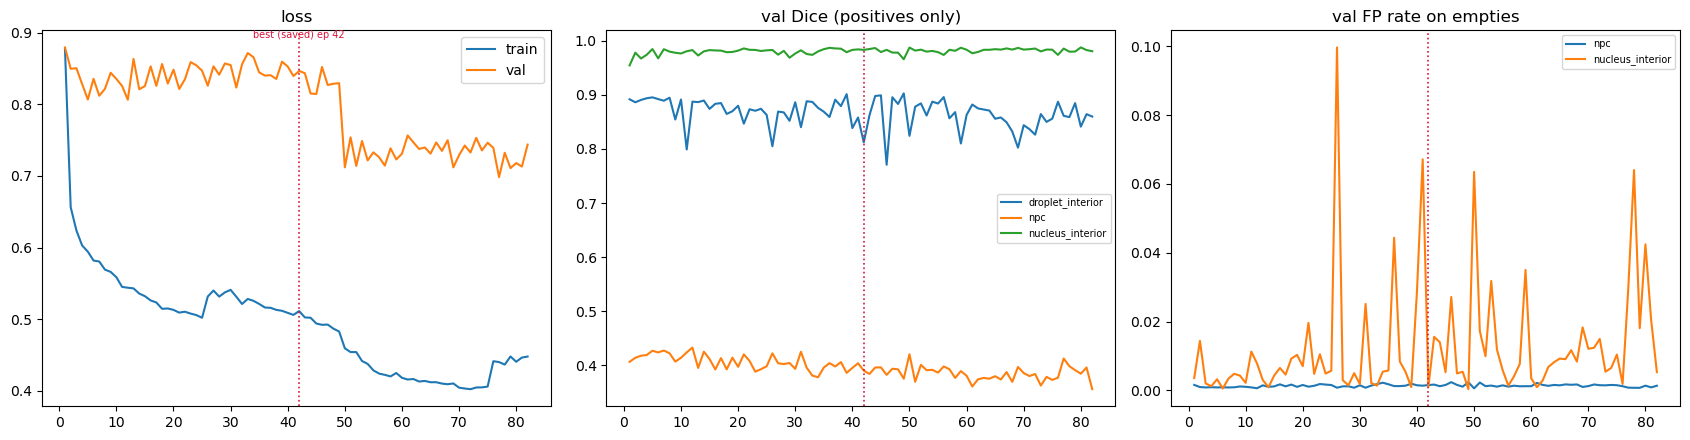

In [16]:
def plot_history(hist, cfg=cfg):
    h = hist.history; ep = range(1, len(h["loss"]) + 1)
    # The checkpoint monitor is nucleus-only, so the saved epoch is not
    # necessarily a good epoch for the droplet head -- mark it so that is visible.
    mon = getattr(cfg, "checkpoint_monitor", "val_nucleus_quality")
    best_ep = (int(max(range(len(h[mon])), key=lambda i: h[mon][i])) + 1) if mon in h else None
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
    ax[0].plot(ep, h["loss"], label="train"); ax[0].plot(ep, h["val_loss"], label="val"); ax[0].set_title("loss"); ax[0].legend()
    for k in h:
        if k.startswith("val_") and k.endswith("_dice"): ax[1].plot(ep, h[k], label=k[4:-5])
    ax[1].set_title("val Dice (positives only)"); ax[1].legend(fontsize=7)
    for k in h:
        if k.startswith("val_") and k.endswith("_fp"): ax[2].plot(ep, h[k], label=k[4:-3])
    if cfg.has_z_head() and "val_z_offset_mae" in h: ax[2].plot(ep, h["val_z_offset_mae"], "k--", label="z_offset MAE (um)")
    ax[2].set_title("val FP rate on empties"); ax[2].legend(fontsize=7)
    if best_ep is not None:
        for a in ax: a.axvline(best_ep, color="crimson", ls=":", lw=1.2)
        ax[0].annotate(f"best (saved) ep {best_ep}", (best_ep, ax[0].get_ylim()[1]),
                       fontsize=7, color="crimson", ha="center", va="top")
    plt.tight_layout(); plt.show()


class _CsvHistory:
    """Adapter so plot_history() works for a run that trained in a batch job.

    model.fit returns a History object and cell 40 keeps it in `histories`, but
    a SLURM run exits with that object in a dead process. CSVLogger's file is
    the only surviving record, so wrap it to look like what plot_history wants.
    """
    def __init__(self, df):
        self.history = {c: df[c].tolist() for c in df.columns if c != "epoch"}


def load_history(seed=None, cfg=cfg, run_dir=None):
    """Read qc/history_s<seed>.csv from the run dir. Returns a History-like object.

    run_dir is derived from a hash of the config, so ANY cfg field that differs
    from the training run moves it -- and `max_parallel_workers` is read from
    SLURM_CPUS_PER_TASK, so merely running in a session with a different
    --cpus-per-task than the training job points cfg.qc_dir at a directory that
    does not exist. When that happens, list the runs that DO exist and let the
    caller pass run_dir= explicitly.
    """
    seed = cfg.seeds[0] if seed is None else seed
    qc = (Path(run_dir) / "qc") if run_dir is not None else cfg.qc_dir
    p = qc / f"history_s{seed}.csv"
    if not p.exists():
        found = sorted((cfg.out_root / "runs").glob(
            f"{cfg.model_name}_p*_*/qc/history_s{seed}.csv"))
        msg = f"no history at {p}"
        if found:
            msg += "\n  runs that DO have a history_s%d.csv:" % seed
            for c in found:
                n = sum(1 for _ in c.open()) - 1
                msg += f"\n    run_dir=Path(r\"{c.parent.parent}\")   ({n} epochs)"
            msg += "\n  re-run as: load_history(run_dir=...)"
        else:
            msg += "\n  (no run under %s has one)" % (cfg.out_root / "runs")
        raise FileNotFoundError(msg)
    df = pd.read_csv(p)
    mon = getattr(cfg, "checkpoint_monitor", "val_nucleus_quality")
    best = int(df[mon].idxmax()) if mon in df.columns else None
    print(f"{p}\n  {len(df)} epochs, {int(df.loss.isna().sum())} NaN"
          + (f", best {mon}={df[mon].max():.4f} at epoch {best}" if best is not None else ""))
    return _CsvHistory(df)


# `histories` exists only if training ran in THIS kernel. After a batch run it
# does not, so fall back to the CSV the run left behind.
try:
    _hists = histories
except NameError:
    _hists = {cfg.seeds[0]: load_history()}
for s, hst in _hists.items():
    print("seed", s); plot_history(hst)

## 16. Inference — tiled, 2.5D, TTA, ensemble

Hann-blended 512 tiles as in 1.1. Each tile gets the same 2.5D context stack
the training patches had. `tta=True` averages the eight dihedral transforms
(plan 11.1). With several seeds, member outputs are averaged and their
per-pixel std on `nucleus_interior` is written as a **disagreement map**
(the review queue, plan 5.2 / 11.4). `mc_dropout` adds `mc_samples`
stochastic passes per member.

Output hyperstack axes `(T, Z, C, Y, X)` with `C = [mask heads..., z_offset,
disagreement]`.

In [30]:
from tensorflow.keras import models as _models
_win = (np.hanning(cfg.patch_size)[:, None] * np.hanning(cfg.patch_size)[None, :]).astype(np.float32)[..., None] + 1e-6
MC_SAMPLES = 8

def _tile_origins(n, p, s):
    if n <= p: return [0]
    xs = list(range(0, n - p + 1, s))
    if xs[-1] != n - p: xs.append(n - p)
    return xs

_DIHEDRAL = [(k, f) for k in range(4) for f in (False, True)]
def _fwd(x, k, f):  return np.rot90(np.flip(x, 1) if f else x, k, axes=(0, 1))
def _inv(y, k, f):
    y = np.rot90(y, -k, axes=(0, 1)); return np.flip(y, 1) if f else y

def predict_tile_batch(members, tiles, cfg=cfg):
    """(B,ps,ps,Cin) -> mean prediction (B,ps,ps,N_MASK+1|N_MASK) and nucleus std over members/TTA."""
    preds = []
    for m in members:
        for k, f in (_DIHEDRAL if cfg.tta else [(0, False)]):
            xb = np.stack([_fwd(t, k, f) for t in tiles])
            reps = MC_SAMPLES if cfg.mc_dropout else 1
            for _ in range(reps):
                p = m(tf.constant(xb), training=False).numpy()[..., :N_MASK + (1 if cfg.has_z_head() else 0)]
                preds.append(np.stack([_inv(pi, k, f) for pi in p]))
    P = np.stack(preds)                       # (n, B, ps, ps, C)
    return P.mean(0), P[..., NUC_COL].std(0)

def predict_plane_stack(members, hs, t, z, cfg=cfg):
    """Full-frame (H, W, C+1) with the last channel = disagreement."""
    n_t, n_z, n_c, H, W = hs.shape; ps = cfg.patch_size
    ctx = context_planes(z, n_z, cfg.n_z_context) if cfg.phase >= 2 else [z]
    planes = []
    for zz in ctx:
        planes.append(np.stack([
            normalize_channel(extract_plane(hs, t, zz, cfg.nucleus_channel_idx), _stats_for(cfg, t, cfg.nucleus_channel_idx)),
            normalize_channel(extract_plane(hs, t, zz, cfg.npc_channel_idx), _stats_for(cfg, t, cfg.npc_channel_idx)),
            normalize_channel(extract_plane(hs, t, zz, cfg.membrane_channel_idx), _stats_for(cfg, t, cfg.membrane_channel_idx))], -1))
    full = np.concatenate(planes, -1)         # (H, W, Cin). NOTE: full-frame normalisation,
                                              # not per-tile — matches "per_patch" only approximately.
    C = N_MASK + (1 if cfg.has_z_head() else 0)
    acc = np.zeros((H, W, C), np.float32); dis = np.zeros((H, W), np.float32); wsum = np.zeros((H, W, 1), np.float32)
    origins = [(y, x) for y in _tile_origins(H, ps, cfg.tile_stride) for x in _tile_origins(W, ps, cfg.tile_stride)]
    for i in range(0, len(origins), cfg.infer_batch):
        chunk = origins[i:i + cfg.infer_batch]
        tiles = np.stack([full[y:y+ps, x:x+ps] for (y, x) in chunk])
        pm, ps_ = predict_tile_batch(members, tiles, cfg)
        for (y, x), p, s in zip(chunk, pm, ps_):
            acc[y:y+ps, x:x+ps] += p * _win; dis[y:y+ps, x:x+ps] += s * _win[..., 0]; wsum[y:y+ps, x:x+ps] += _win
    out = acc / np.maximum(wsum, 1e-6)
    return np.concatenate([out, (dis / np.maximum(wsum[..., 0], 1e-6))[..., None]], -1)

def run_inference(cfg=cfg, t_range=None, z_range=None, which="best"):
    members = [_models.load_model(str(cfg.model_path(s, which)), compile=False) for s in cfg.seeds]
    hs = load_memmap_tiff(cfg.image_file); n_t, n_z, n_c, H, W = hs.shape
    t_range = list(t_range or range(n_t)); z_range = list(z_range or range(n_z))
    C = N_MASK + (1 if cfg.has_z_head() else 0) + 1
    path = cfg.qc_dir / f"inference_prob_{which}.tif"
    mm = tiff.memmap(str(path), shape=(len(t_range), len(z_range), C, H, W), dtype=np.float32, bigtiff=True)
    print(f"{len(t_range)*len(z_range)} planes, {len(members)} members, tta={cfg.tta} -> {path} (~{mm.nbytes/1e9:.1f} GB)")
    for ti, t in enumerate(tqdm(t_range, desc="t")):
        for zi, z in enumerate(z_range):
            mm[ti, zi] = np.transpose(predict_plane_stack(members, hs, t, z, cfg), (2, 0, 1))
        mm.flush()
    json.dump({"t_range": t_range, "z_range": z_range, "channels": MASK_HEADS + (["z_offset"] if cfg.has_z_head() else []) + ["disagreement"]},
              open(cfg.qc_dir / f"inference_prob_{which}.json", "w"))
    return path

PROB_PATH = run_inference(cfg)

2026-09-16 09:36:00.434613: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79078 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0


NameError: name 'N_MASK' is not defined

## 17. Post-processing — instances, best-Z, watershed

`extract_detections` turns the probability hyperstack into a per-plane
detection table: label `nucleus_interior`, assign each object to a droplet
(from the predicted `droplet_interior`, linked across z as in 1.1 to get
`z_eq_droplet` and `R_um`), and compute `rho0 = |z - z_eq| * dz / R` — the
geometric impossibility metric (plan 2.1).

Objects are linked across z by overlap into 3D nuclei. **Best-Z** per nucleus
is `max_area` (1.1) or `argmin(mean predicted z_offset)` (plan 7.2); both are
recorded so they can be compared on the gold set.

**Watershed (plan 7.1)** runs in the NLS channel on a **contrast-normalised**
gradient — gradient magnitude divided by the local intensity range — so it is
driven by edge sharpness, not edge height (which is the N/C ratio). Markers
are the eroded predicted cores; the barrier adds `nucleus_edge`.

In [ ]:
# normalized_sharpness() is defined in Section 5c and shared with the labeler.

def watershed_nuclei(nls, p_core, p_edge, cfg=cfg):
    """Instance labels from predicted core + edge, elevation = sharpness + edge prob."""
    core = p_core > cfg.watershed_core_thresh
    core = morphology.binary_erosion(core, morphology.disk(2))
    # Seeds from distance-transform peaks inside the core, not from connected
    # components: two touching nuclei usually share one predicted core blob.
    dist = distance_transform_edt(core)
    comp = measure.label(core)
    peaks = peak_local_max(dist, min_distance=int(cfg.watershed_min_marker_dist_px),
                           labels=comp, exclude_border=False)
    markers = np.zeros(core.shape, np.int32)
    for i, (py, px) in enumerate(peaks, 1): markers[py, px] = i
    if markers.max() == 0: markers = comp
    mask = (p_core > cfg.mask_threshold) | (p_edge > cfg.mask_threshold)
    elev = normalized_sharpness(nls, cfg=cfg) + cfg.watershed_edge_weight * p_edge
    return watershed(elev, markers, mask=mask)

def droplet_geometry_from_masks(drop_stack, cfg=cfg):
    """
    drop_stack (Z, H, W) bool of predicted droplet_interior for one t.
    Returns list of {"z_eq", "R_um", "cx", "cy", "prof": {z: r_px}} per droplet.
    """
    dets = []
    for z in range(drop_stack.shape[0]):
        for r in measure.regionprops(measure.label(drop_stack[z])):
            if r.area < cfg.min_droplet_area_px(): continue
            dets.append({"z": z, "x": r.centroid[1], "y": r.centroid[0], "r": np.sqrt(r.area / np.pi)})
    if not dets: return []
    xy = np.array([[d["x"], d["y"]] for d in dets])
    lab = DBSCAN(eps=cfg.drift_tolerance_um / cfg.pixel_size_um, min_samples=cfg.dbscan_min_planes).fit_predict(xy)
    out = []
    for l in set(lab) - {-1}:
        grp = [d for d, li in zip(dets, lab) if li == l]
        prof = {}
        for d in grp: prof[d["z"]] = max(prof.get(d["z"], 0), d["r"])
        z_eq = max(prof, key=prof.get)
        out.append({"z_eq": z_eq, "R_um": prof[z_eq] * cfg.pixel_size_um, "prof": prof,
                    "cx": np.mean([d["x"] for d in grp]), "cy": np.mean([d["y"] for d in grp])})
    return out

def extract_detections(prob_path, cfg=cfg, use_watershed=None):
    """Per-plane nucleus detections -> DataFrame; 3D linking -> nucleus_id, best_z flags."""
    meta = json.load(open(str(prob_path).replace(".tif", ".json"))); ch = {n: i for i, n in enumerate(meta["channels"])}
    mm = tiff.memmap(str(prob_path)); hs = load_memmap_tiff(cfg.image_file)
    use_ws = cfg.watershed if use_watershed is None else use_watershed
    rows = []; px2 = cfg.pixel_size_um ** 2
    for ti, t in enumerate(meta["t_range"]):
        drop_stack = np.asarray(mm[ti, :, ch["droplet_interior"]] > cfg.mask_threshold)
        drops = droplet_geometry_from_masks(drop_stack, cfg)
        dxy = np.array([[d["cx"], d["cy"]] for d in drops]) if drops else np.empty((0, 2))
        lab3d = np.zeros(drop_stack.shape, np.int32); nxt = 1; prev = None; prev_area = {}
        for zi, z in enumerate(meta["z_range"]):
            p_core = np.asarray(mm[ti, zi, ch["nucleus_interior"]])
            if use_ws:
                p_edge = np.asarray(mm[ti, zi, ch["nucleus_edge"]]) if "nucleus_edge" in ch else np.zeros_like(p_core)
                lab = watershed_nuclei(extract_plane(hs, t, z, cfg.nucleus_channel_idx), p_core, p_edge, cfg)
            else:
                lab = measure.label(p_core > cfg.mask_threshold)
            zo = np.asarray(mm[ti, zi, ch["z_offset"]]) if "z_offset" in ch else None
            dis = np.asarray(mm[ti, zi, ch["disagreement"]])
            # link to previous plane by max overlap -> 3D nucleus ids
            cur = np.zeros_like(lab)
            for r in measure.regionprops(lab):
                m = lab == r.label
                nid = None
                if prev is not None:
                    ov = prev[m]; ov = ov[ov > 0]
                    if ov.size:
                        cand = int(np.bincount(ov).argmax()); n_ov = int((ov == cand).sum())
                        # overlap relative to the SMALLER of the two sections, so a
                        # nucleus growing toward its equator links to its own cap
                        if n_ov > 0.3 * min(r.area, prev_area.get(cand, r.area)): nid = cand
                if nid is None: nid = nxt; nxt += 1
                cur[m] = nid
                cy, cx = r.centroid
                if len(dxy):
                    k = int(np.argmin(((dxy - [cx, cy]) ** 2).sum(1))); d = drops[k]
                    rho0 = abs(z - d["z_eq"]) * cfg.z_step_um / d["R_um"]; R_um = d["R_um"]; did = k
                    chord_ok = r.feret_diameter_max <= 2 * d["prof"].get(z, d["R_um"] / cfg.pixel_size_um) * (1 + cfg.chord_tol_frac)
                else:
                    rho0 = np.nan; R_um = np.nan; did = -1; chord_ok = True
                rows.append(dict(t=t, z=z, nucleus_id=nid, droplet_id=did, area_um2=r.area * px2,
                                 cx=cx, cy=cy, rho0=rho0, R_um=R_um, chord_ok=chord_ok,
                                 mean_p=float(p_core[m].mean()), mean_disagreement=float(dis[m].mean()),
                                 mean_z_offset=float(zo[m].mean()) if zo is not None else np.nan))
            prev = cur; lab3d[zi] = cur
            prev_area = {int(k): int(v) for k, v in zip(*np.unique(cur[cur > 0], return_counts=True))}
    df = pd.DataFrame(rows)
    if df.empty: return df
    df["key"] = list(zip(df.t, df.nucleus_id))
    df["best_z_max_area"] = df.groupby("key")["area_um2"].transform("max") == df["area_um2"]
    if "z_offset" in ch:
        df["best_z_argmin_zoff"] = df.groupby("key")["mean_z_offset"].transform("min") == df["mean_z_offset"]
    else:
        df["best_z_argmin_zoff"] = df["best_z_max_area"]
    df["is_best_z"] = df["best_z_argmin_zoff"] if cfg.best_z_mode == "argmin_z_offset" else df["best_z_max_area"]
    df["n_planes"] = df.groupby("key")["z"].transform("count")
    df["epoch"] = np.where(df.t <= 2, "early", np.where(df.t >= 7, "late", "mid"))
    return df.drop(columns="key")

det_df = extract_detections(PROB_PATH, cfg)
det_df.to_csv(cfg.qc_dir / "detections.csv", index=False)
print(det_df.groupby(["t"])["nucleus_id"].nunique().to_dict())

## 18. `evaluate_inference()` — plan Section 2 acceptance gates

Computed on the detection table, never on Dice. Every metric is reported
overall and for early (t=0-2) / late (t=7-9) separately, because the
aggregate is how a 48% CV coexisted with acceptable Dice.

| gate | definition here |
|---|---|
| area CV at final t | CV of best-z areas at `t_max` |
| plateau fraction at t=2 | best-z count at t=2 / median count over t=3..t_max |
| stability t=3->end | max / min of per-frame best-z counts |
| impossible-plane FP | fraction of all per-plane detections with `rho0` in the window |
| median area at final t | median best-z area at `t_max` |
| mass proxy (anti-gate) | count x median area at final t; must not fall vs baseline |

`compare_to_baseline` reads a saved evaluation (e.g. Vulcan 1.1's) and flags
regressions. The treated-data anti-gate and tracker-dependent metrics are
reported as **blocked** until their inputs exist.

In [32]:
def evaluate_inference(det_df, cfg=cfg, gold_df=None, label=None):
    d = det_df.copy(); best = d[d.is_best_z]
    t_max = int(d.t.max()); counts = best.groupby("t")["nucleus_id"].nunique().reindex(range(t_max + 1), fill_value=0)
    plateau = counts.loc[3:].median() if t_max >= 3 else np.nan
    fin = best[best.t == t_max]["area_um2"]
    window = cfg.rho0_impossible_window
    imp = d[(d.rho0 >= window[0]) & (d.rho0 <= window[1])]
    fp_imp = len(imp) / max(len(d), 1)
    m = {
        "area_cv_final":      (fin.std() / fin.mean() if len(fin) > 1 else np.nan, "<=", cfg.gate_area_cv_final),
        "plateau_frac_t2":    (counts.get(2, 0) / plateau if plateau else np.nan, ">=", cfg.gate_plateau_frac_t2),
        "stability_t3_end":   (counts.loc[3:].max() / max(counts.loc[3:].min(), 1) if t_max >= 3 else np.nan, "<=", cfg.gate_stability_ratio),
        "impossible_plane_fp": (fp_imp, "<", cfg.gate_impossible_fp),
        "median_area_final":  (fin.median(), ">=", cfg.gate_median_area_final_um2),
    }
    anti = {
        "mass_proxy_final": counts.get(t_max, 0) * (fin.median() if len(fin) else 0),
        "detections_per_frame": counts.to_dict(),
        "chord_violation_frac": float((~d.chord_ok).mean()),
        "single_plane_nucleus_frac": float((best.n_planes == 1).mean()) if len(best) else np.nan,
        "treated_recall_vs_1_1": "BLOCKED: no treated dataset (plan Phase 5)",
        "single_frame_track_frac": "BLOCKED: tracker cannot express gaps (plan 2.2)",
    }
    per_epoch = {}
    for ep, g in best.groupby("epoch"):
        a = g.area_um2
        per_epoch[ep] = dict(n=int(g.nucleus_id.nunique()), median_area=float(a.median()),
                             area_cv=float(a.std() / a.mean()) if len(a) > 1 else np.nan,
                             impossible_fp=float(((d[d.epoch == ep].rho0.between(*window))).mean()))
    if gold_df is not None:
        per_epoch["gold_agreement"] = "TODO: match best-z detections to gold by IoU per timepoint"
    ok = all((v[0] <= v[2]) if v[1] in ("<=", "<") else (v[0] >= v[2]) for v in m.values() if not np.isnan(v[0]))
    report = {"label": label or cfg.run_dir.name, "phase": cfg.phase, "best_z_mode": cfg.best_z_mode,
              "gates": {k: dict(value=float(v[0]), op=v[1], gate=v[2],
                                passed=bool((v[0] <= v[2]) if v[1] in ("<=", "<") else (v[0] >= v[2])) if not np.isnan(v[0]) else None)
                        for k, v in m.items()},
              "anti_gates": anti, "per_epoch": per_epoch, "all_gates_passed": ok}
    print(f"== {report['label']}  phase {cfg.phase}  best_z={cfg.best_z_mode} ==")
    for k, v in report["gates"].items():
        print(f"  {k:22s} {v['value']:8.3f}  {v['op']} {v['gate']:<6}  {'PASS' if v['passed'] else 'FAIL' if v['passed'] is not None else 'n/a'}")
    print("  detections/frame:", anti["detections_per_frame"])
    print("  mass proxy:", round(anti["mass_proxy_final"]), " chord violations:", round(anti["chord_violation_frac"], 3))
    for ep, v in per_epoch.items(): print(f"  [{ep}] {v}")
    return report

def compare_to_baseline(report, baseline_path):
    base = json.load(open(baseline_path)); print(f"\nvs baseline {base['label']}:")
    for k, v in report["gates"].items():
        b = base["gates"].get(k, {}).get("value"); 
        if b is None or v["value"] is None: continue
        better = (v["value"] < b) if v["op"] in ("<", "<=") else (v["value"] > b)
        print(f"  {k:22s} {b:8.3f} -> {v['value']:8.3f}  {'better' if better else 'WORSE'}")
    bm, rm = base["anti_gates"].get("mass_proxy_final"), report["anti_gates"]["mass_proxy_final"]
    if bm: print(f"  mass proxy {bm:.0f} -> {rm:.0f}  {'OK' if rm >= 0.95 * bm else 'ANTI-GATE FAIL: recall bought too expensively'}")

report = evaluate_inference(det_df, cfg)
json.dump(report, open(cfg.qc_dir / "evaluation.json", "w"), indent=2, default=str)
_baseline = cfg.out_root / "runs" / "baseline_Vulcan_1.1_evaluation.json"
if _baseline.exists(): compare_to_baseline(report, _baseline)
else: print(f"\nno baseline at {_baseline}: run Section 17-18 against the 1.1 inference output first (Phase 0 step 3)")

NameError: name 'det_df' is not defined

In [17]:
# Best-Z selector comparison (plan 7.2): how often does argmin(z_offset) pick a
# different plane than max area, and by how much do the areas differ? Only
# informative from phase 3 on; before that the two columns are identical.
if cfg.has_z_head():
    b1 = det_df[det_df.best_z_max_area].set_index(["t", "nucleus_id"])["area_um2"]
    b2 = det_df[det_df.best_z_argmin_zoff].set_index(["t", "nucleus_id"])["area_um2"]
    j = b1.to_frame("max_area").join(b2.to_frame("argmin_zoff"), how="inner")
    diff = (j.max_area != j.argmin_zoff)
    print(f"selector disagreement: {diff.mean():.1%} of nuclei; median area ratio where they differ: "
          f"{(j.argmin_zoff / j.max_area)[diff].median():.3f}")
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    for t, g in det_df[det_df.is_best_z].groupby("t"): ax[0].hist(g.area_um2, bins=40, alpha=0.3, label=f"t{t}")
    ax[0].set_title("best-z area by t"); ax[0].legend(fontsize=6)
    ax[1].scatter(j.max_area, j.argmin_zoff, s=4); ax[1].plot([0, 600], [0, 600], "k--"); ax[1].set_xlabel("max-area"); ax[1].set_ylabel("argmin z_offset")
    plt.tight_layout(); plt.show()

## 19. SLURM / tunnel reference and phase run order

```
srun --partition=amperenodes --gres=gpu:1 --ntasks=1 --cpus-per-task=8 --mem=32G --time=4:00:00 --pty bash
~/.vscode/cli/code tunnel --name star-forge
```

Patch generation for 10 timepoints with a 17-plane extent scan is heavier
than 1.1 (every plane now gets the nucleus detector); budget one 4 h window.
Do not read a non-trivial `t=0-3` positive count as confirmation — the count
says the detector fired, not that it found anything. `review_status()` in 9.5d
is the check that distinguishes the two.

### Run order (plan Section 9)

1. **Phase 0** — Sections 16-18 against the 1.1 model to write
   `baseline_Vulcan_1.1_evaluation.json`.
2. **Phase 1** — `cfg = PipelineConfig(phase=1)`; generate; train; evaluate.
   Gate: does t=9 area CV move? If not, stop and re-diagnose.
3. **Phase 2** — `phase=2`, same patches (gen_hash unchanged); train; evaluate.
   If droplet/NPC Dice regress, drop `droplet_edge` first (plan Section 10).
4. **Phase 3** — `phase=3`; compare `best_z_argmin_zoff` vs `max_area` on the gold set.
5. **Phase 4** — watershed; validate on two-nucleus droplets in 9.5c.
6. Tier-1 flags (`seeds`, `tta`, `aug_*`, `use_focal_tversky_nucleus`) are
   already on where cheap; toggle **one at a time** against Section 18 when
   attributing.